# Notebook 2. FCCU Machine-Learning Workflow

This notebook performs the full leakage-aware preparation of the FCCU dataset for classical machine-learning models.
It is intentionally separated from the deep-learning notebook so that ML benchmarking runs in an independent kernel with a simpler numerical stack.

Scope:
- loading and auditing the dataset,
- chronological scenario-aware preprocessing,
- exogenous-only and ARX-like ML baselines,
- compact publication-oriented comparison tables and figures.

In [1]:
import gc
import os
import platform
import random
import time
import warnings
from pathlib import Path

os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('VECLIB_MAXIMUM_THREADS', '1')
os.environ.setdefault('NUMEXPR_NUM_THREADS', '1')
os.environ.setdefault('BLIS_NUM_THREADS', '1')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import sklearn
import statsmodels
from IPython.display import Markdown, display

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, MultiTaskElasticNet, Ridge
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

SEED = 42
CSV_PATH = Path('FCCU_DYNAMIC_NN_DATASET.csv')
CPU_THREAD_BUDGET = 1
INFERENCE_TIME_REPEATS = 3
INTERACTIVE_FIG_DPI = 350
EXPORT_FIG_DPI = 350
LIGHTGBM_AVAILABLE = False
LIGHTGBM_IMPORT_NOTE = 'excluded from the ML notebook to avoid Apple Silicon libomp kernel instability'


def set_global_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)


def synchronize_torch_device(device=None):
    return None


set_global_seed(SEED)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', message='findfont')

mpl.rcParams.update({
    'figure.dpi': 350,
    'savefig.dpi': 350,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 18,
    'axes.titlesize': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'legend.title_fontsize': 18,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

assert CSV_PATH.exists(), f'Missing file: {CSV_PATH}'

runtime_df = pd.DataFrame([{
    'python': platform.python_version(),
    'platform': platform.platform(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'scikit_learn': sklearn.__version__,
    'statsmodels': statsmodels.__version__,
    'matplotlib': mpl.__version__,
    'cpu_thread_budget': CPU_THREAD_BUDGET,
    'figure_dpi': 350,
    'lightgbm_policy': 'excluded from the ML notebook to avoid Apple Silicon libomp kernel instability',
}])
display(runtime_df)


,python,platform,numpy,pandas,scikit_learn,statsmodels,matplotlib,cpu_thread_budget,figure_dpi,lightgbm_policy
0,3.11.14,macOS-26.4-arm64-arm-64bit,2.4.4,2.3.3,1.8.0,0.14.6,3.10.8,1,350,excluded from the ML notebook to avoid Apple S...


## A. Problem Framing and Variable Mapping

The DOCX requests a dynamic recurrent neural network workflow for FCCU product-yield forecasting using time-series process data, with recurrent models as the core family, strong baselines, physically meaningful constraints when justified, and publication-ready outputs.

The CSV is not a direct one-to-one match with the idealized variables named in the DOCX. The notebook therefore builds the study around the real columns and maps the intended process variables to the strongest available equivalents.


In [2]:
df_raw = pd.read_csv(CSV_PATH)
print(f'CSV shape: {df_raw.shape}')
print('CSV columns:')
for idx, col in enumerate(df_raw.columns, start=1):
    print(f'{idx:02d}. {col}')
primary_targets = [
    'gasoline_proxy_wt_pct_of_feed',
    'light_cycle_oil_wt_pct_of_feed',
    'lpg_wt_pct_of_feed',
    'slurry_wt_pct_of_feed',
]
aux_target = 'measured_products_wt_pct_of_feed'
recommended_feature_cols = [
    'feed_flow_tph',
    'ambient_temperature_Tatm_degF',
    'feed_temperature_T1_degF',
    'reactor_inlet_feed_temperature_T2_degF',
    'reactor_riser_temperature_Tr_degC',
    'regenerator_temperature_Treg_degF',
    'reactor_pressure_P4_psia',
    'regenerator_minus_reactor_pressure_deltaP_psig',
    'regenerator_pressure_P6_psia',
    'regenerator_total_air_flow_Fair_mol_s',
    'furnace_firebox_temperature_T3_degF',
    'standpipe_catalyst_level_Lsp_ft',
    'stack_gas_temperature_Tcyc_degF',
    'stack_gas_minus_regenerator_temperature_Tcyc_Treg_degF',
    'stack_gas_co_Cco_g_ppm',
    'stack_gas_o2_Co2_g_mol_pct',
    'fractionator_overhead_pressure_P5_psia',
    'regenerated_catalyst_flow_Frgc_lb_min',
    'spent_catalyst_flow_Fsc_lb_min',
    'combustion_air_blower_current_ACAB_amp',
]
extended_feature_cols = recommended_feature_cols + [
    'wet_gas_compressor_current_AWGC_amp',
    'furnace_fuel_flow_F5_scf_min',
    'combustion_air_flow_F7_lb_min',
    'stack_gas_flow_Fsg_mol_min',
    'cab_suction_pressure_P1_psia',
    'cab_discharge_pressure_P2_psia',
    'fractionator_overhead_temperature_Tfra_degF',
    'fractionator_mid_temperature_T10_degF',
    'fractionator_bottom_temperature_T20_degF',
    'valve_fractionator_pressure_V4_pct',
    'valve_regenerator_temperature_V6_pct',
    'valve_regenerator_pressure_V7_pct',
    'valve_reactor_inventory_V3_pct',
    'valve_preheated_feed_temperature_V1_pct',
    'valve_reactor_temperature_V2_pct',
    'valve_accumulator_level_V9_pct',
    'valve_fractionator_temperature_V8_pct',
]
identifier_cols = ['dataset_row_id', 'scenario_id', 'source_file', 'row_in_scenario']
time_cols = ['time_min', 'time_hour', 'time_day']
split_cols = ['dataset_split']
condition_cols = ['condition', 'is_faulty_scenario', 'fault_type', 'fault_start_min', 'fault_transition_end_min']
leakage_prone_cols = ['operating_phase', 'is_after_fault_start', 'time_since_fault_start_min', 'time_since_fault_start_hour']
mapping_rows = [
    ('Reactor temperature', 'reactor_riser_temperature_Tr_degC', 'Direct engineering-unit match', 'used'),
    ('Feed flow', 'feed_flow_tph', 'Direct engineering-unit match', 'used'),
    ('Catalyst activity', 'No direct column', 'Unavailable; approximated indirectly by circulation and regenerator proxies', 'not directly used'),
    ('Feed API gravity', 'No direct column', 'Unavailable in the CSV', 'not available'),
    ('Feed sulfur content', 'No direct column', 'Unavailable in the CSV', 'not available'),
    ('Gasoline yield', 'gasoline_proxy_wt_pct_of_feed', 'Proxy equal to light plus heavy naphtha yield', 'primary target'),
    ('Light gas oil yield', 'light_cycle_oil_wt_pct_of_feed', 'Direct available yield proxy', 'primary target'),
    ('Dry gas yield', 'lpg_wt_pct_of_feed', 'Only light-gas-style yield available; not identical to dry gas', 'surrogate target'),
    ('Coke yield', 'No direct column', 'Unavailable; slurry is not treated as coke', 'not claimed'),
    ('Heavy bottoms / slurry', 'slurry_wt_pct_of_feed', 'Available heavy-bottoms product yield', 'primary target'),
    ('Measured total product yield', 'measured_products_wt_pct_of_feed', 'Exact sum of selected product-yield targets', 'auxiliary constraint target'),
]
mapping_df = pd.DataFrame(mapping_rows, columns=['Process concept', 'CSV mapping', 'Scientific interpretation', 'Notebook role'])
display(mapping_df)
summary_points = [
    'The CSV already contains chronological scenario metadata, split labels, and process measurements.',
    'The primary modeling task is multi-output forecasting of four yield-style targets in wt% of feed.',
    'The main recurrent comparison uses exogenous process variables only, because that is the most conservative causal framing.',
    'Autoregressive classical baselines are included separately and labeled as using a richer information set.',
    'Fault-timing metadata are retained for analysis only and are excluded from model inputs to avoid leakage.',
]
display(Markdown('\n'.join(f'- {point}' for point in summary_points)))
candidate_inputs_df = pd.DataFrame({
    'selected_exogenous_feature': extended_feature_cols,
    'feature_group': ['recommended'] * len(recommended_feature_cols) + ['extended'] * (len(extended_feature_cols) - len(recommended_feature_cols)),
})
display(candidate_inputs_df)
print('Candidate primary targets:', primary_targets)
print('Auxiliary consistency target:', aux_target)
print('Identifiers:', identifier_cols)
print('Time variables:', time_cols)
print('Split variable:', split_cols)
print('Condition indicators retained for analysis only:', condition_cols + leakage_prone_cols)

# ==== MARKDOWN CELL 4: ## B. Data Loading and Audit ====


# ==== MARKDOWN CELL 4: ## B. Data Loading and Audit ====


CSV shape: (20160, 75)
CSV columns:
01. dataset_row_id
02. scenario_id
03. condition
04. operating_phase
05. dataset_split
06. fault_type
07. source_file
08. row_in_scenario
09. time_min
10. time_hour
11. time_day
12. is_faulty_scenario
13. fault_start_min
14. fault_transition_end_min
15. is_after_fault_start
16. time_since_fault_start_min
17. time_since_fault_start_hour
18. feed_flow_lb_min
19. feed_flow_tph
20. reactor_riser_temperature_Tr_degC
21. gasoline_proxy_flow_lb_min
22. measured_products_flow_lb_min
23. lpg_wt_pct_of_feed
24. light_naphtha_wt_pct_of_feed
25. heavy_naphtha_wt_pct_of_feed
26. gasoline_proxy_wt_pct_of_feed
27. light_cycle_oil_wt_pct_of_feed
28. slurry_wt_pct_of_feed
29. measured_products_wt_pct_of_feed
30. feed_flow_F3_lb_s
31. ambient_temperature_Tatm_degF
32. feed_temperature_T1_degF
33. reactor_inlet_feed_temperature_T2_degF
34. reactor_riser_temperature_Tr_degF
35. regenerator_temperature_Treg_degF
36. reactor_pressure_P4_psia
37. regenerator_minus_reactor_

,Process concept,CSV mapping,Scientific interpretation,Notebook role
0,Reactor temperature,reactor_riser_temperature_Tr_degC,Direct engineering-unit match,used
1,Feed flow,feed_flow_tph,Direct engineering-unit match,used
2,Catalyst activity,No direct column,Unavailable; approximated indirectly by circul...,not directly used
3,Feed API gravity,No direct column,Unavailable in the CSV,not available
4,Feed sulfur content,No direct column,Unavailable in the CSV,not available
5,Gasoline yield,gasoline_proxy_wt_pct_of_feed,Proxy equal to light plus heavy naphtha yield,primary target
6,Light gas oil yield,light_cycle_oil_wt_pct_of_feed,Direct available yield proxy,primary target
7,Dry gas yield,lpg_wt_pct_of_feed,Only light-gas-style yield available; not iden...,surrogate target
8,Coke yield,No direct column,Unavailable; slurry is not treated as coke,not claimed
9,Heavy bottoms / slurry,slurry_wt_pct_of_feed,Available heavy-bottoms product yield,primary target


- The CSV already contains chronological scenario metadata, split labels, and process measurements.
- The primary modeling task is multi-output forecasting of four yield-style targets in wt% of feed.
- The main recurrent comparison uses exogenous process variables only, because that is the most conservative causal framing.
- Autoregressive classical baselines are included separately and labeled as using a richer information set.
- Fault-timing metadata are retained for analysis only and are excluded from model inputs to avoid leakage.

,selected_exogenous_feature,feature_group
0,feed_flow_tph,recommended
1,ambient_temperature_Tatm_degF,recommended
2,feed_temperature_T1_degF,recommended
3,reactor_inlet_feed_temperature_T2_degF,recommended
4,reactor_riser_temperature_Tr_degC,recommended
5,regenerator_temperature_Treg_degF,recommended
6,reactor_pressure_P4_psia,recommended
7,regenerator_minus_reactor_pressure_deltaP_psig,recommended
8,regenerator_pressure_P6_psia,recommended
9,regenerator_total_air_flow_Fair_mol_s,recommended


Candidate primary targets: ['gasoline_proxy_wt_pct_of_feed', 'light_cycle_oil_wt_pct_of_feed', 'lpg_wt_pct_of_feed', 'slurry_wt_pct_of_feed']
Auxiliary consistency target: measured_products_wt_pct_of_feed
Identifiers: ['dataset_row_id', 'scenario_id', 'source_file', 'row_in_scenario']
Time variables: ['time_min', 'time_hour', 'time_day']
Split variable: ['dataset_split']
Condition indicators retained for analysis only: ['condition', 'is_faulty_scenario', 'fault_type', 'fault_start_min', 'fault_transition_end_min', 'operating_phase', 'is_after_fault_start', 'time_since_fault_start_min', 'time_since_fault_start_hour']


## B. Data Loading and Audit

This section checks basic integrity, missingness, split consistency, target distributions, and engineering consistency of the pre-engineered FCCU dataset.


In [3]:
def contiguous_split_order_ok(group: pd.DataFrame) -> bool:
    expected_order = ['train', 'validation', 'test']
    numeric = [expected_order.index(x) for x in group['dataset_split'].tolist()]
    return numeric == sorted(numeric)


df = df_raw.copy()
mem_mb = df.memory_usage(deep=True).sum() / 1024**2
shape_df = pd.DataFrame({'n_rows': [df.shape[0]], 'n_columns': [df.shape[1]], 'memory_mb': [round(mem_mb, 3)], 'duplicate_rows': [int(df.duplicated().sum())]})
display(shape_df)

dtype_df = pd.DataFrame({'column': df.dtypes.index, 'dtype': df.dtypes.astype(str).values})
display(dtype_df.head(20))

missing_df = df.isna().sum().rename('missing_count').reset_index().rename(columns={'index': 'column'})
missing_df['missing_pct'] = 100 * missing_df['missing_count'] / len(df)
display(missing_df.query('missing_count > 0').sort_values(['missing_count', 'column'], ascending=[False, True]))

scenario_split_counts = df.groupby(['scenario_id', 'dataset_split']).size().unstack(fill_value=0)
display(scenario_split_counts)

scenario_audit_rows = []
for scenario_id, group in df.sort_values(['scenario_id', 'time_min']).groupby('scenario_id'):
    scenario_audit_rows.append({
        'scenario_id': scenario_id,
        'rows': len(group),
        'condition': group['condition'].iloc[0],
        'fault_type': group['fault_type'].iloc[0],
        'time_monotonic': bool(group['time_min'].is_monotonic_increasing),
        'split_order_ok': contiguous_split_order_ok(group),
        'row_index_monotonic': bool(group['row_in_scenario'].is_monotonic_increasing),
        'n_unique_splits': group['dataset_split'].nunique(),
    })
scenario_audit_df = pd.DataFrame(scenario_audit_rows)
display(scenario_audit_df)

unit_checks = pd.DataFrame([
    {'check': 'Tr degC matches converted Tr degF', 'max_abs_error': (df['reactor_riser_temperature_Tr_degC'] - ((df['reactor_riser_temperature_Tr_degF'] - 32.0) * 5.0 / 9.0)).abs().max()},
    {'check': 'feed tph matches converted lb/min', 'max_abs_error': (df['feed_flow_tph'] - (df['feed_flow_lb_min'] * 0.45359237 * 60.0 / 1000.0)).abs().max()},
    {'check': 'gasoline proxy yield equals light plus heavy naphtha yield', 'max_abs_error': (df['gasoline_proxy_wt_pct_of_feed'] - (df['light_naphtha_wt_pct_of_feed'] + df['heavy_naphtha_wt_pct_of_feed'])).abs().max()},
    {'check': 'measured products yield equals selected yield sum', 'max_abs_error': (df[aux_target] - df[primary_targets].sum(axis=1)).abs().max()},
])
display(unit_checks)

target_summary = df[primary_targets + [aux_target]].describe().T
target_summary['iqr'] = target_summary['75%'] - target_summary['25%']
display(target_summary)

quality_report = pd.DataFrame([
    ('duplicate_rows', int(df.duplicated().sum())),
    ('feature_columns_with_missing_values', int(df[extended_feature_cols].isna().sum().gt(0).sum())),
    ('target_columns_with_missing_values', int(df[primary_targets + [aux_target]].isna().sum().gt(0).sum())),
    ('all_scenarios_time_monotonic', bool(scenario_audit_df['time_monotonic'].all())),
    ('all_scenarios_split_order_ok', bool(scenario_audit_df['split_order_ok'].all())),
    ('all_scenarios_row_index_monotonic', bool(scenario_audit_df['row_index_monotonic'].all())),
    ('max_unit_conversion_error', float(unit_checks['max_abs_error'].max())),
], columns=['quality_item', 'value'])
display(quality_report)

print('Concise data quality report:')
for _, row in quality_report.iterrows():
    print(f"- {row['quality_item']}: {row['value']}")


# ==== MARKDOWN CELL 6: ## C. Exploratory Data Analysis for Time-Series FCCU Modeling ====


# ==== MARKDOWN CELL 6: ## C. Exploratory Data Analysis for Time-Series FCCU Modeling ====


,n_rows,n_columns,memory_mb,duplicate_rows
0,20160,75,18.855,0


,column,dtype
0,dataset_row_id,int64
1,scenario_id,object
2,condition,object
3,operating_phase,object
4,dataset_split,object
5,fault_type,object
6,source_file,object
7,row_in_scenario,int64
8,time_min,int64
9,time_hour,float64


,column,missing_count,missing_pct
12,fault_start_min,12960,64.285714
13,fault_transition_end_min,12960,64.285714
16,time_since_fault_start_hour,12960,64.285714
15,time_since_fault_start_min,12960,64.285714


dataset_split,test,train,validation
scenario_id,,,
cab_valve_leak,216,1008,216
condenser_efficiency_decrease,216,1008,216
fhn_sensor_drift,216,1008,216
heat_exchanger_fouling,216,1008,216
noc_stable_feed_flow,432,2016,432
noc_varying_feed_flow,1512,7056,1512
reactor_fractionator_pressure_drop_increase,216,1008,216


,scenario_id,rows,condition,fault_type,time_monotonic,split_order_ok,row_index_monotonic,n_unique_splits
0,cab_valve_leak,1440,faulty,cab_valve_leak,True,True,True,3
1,condenser_efficiency_decrease,1440,faulty,condenser_efficiency_decrease,True,True,True,3
2,fhn_sensor_drift,1440,faulty,fhn_sensor_drift,True,True,True,3
3,heat_exchanger_fouling,1440,faulty,heat_exchanger_fouling,True,True,True,3
4,noc_stable_feed_flow,2880,normal,none,True,True,True,3
5,noc_varying_feed_flow,10080,normal,none,True,True,True,3
6,reactor_fractionator_pressure_drop_increase,1440,faulty,pressure_drop_increase,True,True,True,3


,check,max_abs_error
0,Tr degC matches converted Tr degF,1.136868e-13
1,feed tph matches converted lb/min,1.136868e-13
2,gasoline proxy yield equals light plus heavy n...,2.131628e-14
3,measured products yield equals selected yield sum,5.684342e-14


,count,mean,std,min,25%,50%,75%,max,iqr
gasoline_proxy_wt_pct_of_feed,20160.0,46.632783,1.461326,42.855337,46.096293,46.605411,47.354182,50.437116,1.257889
light_cycle_oil_wt_pct_of_feed,20160.0,16.588249,0.099314,16.199761,16.552510,16.600415,16.643480,16.884221,0.090970
lpg_wt_pct_of_feed,20160.0,30.791303,1.451749,27.107628,30.076225,30.834976,31.317421,34.434746,1.241196
slurry_wt_pct_of_feed,20160.0,2.174043,0.107393,1.724233,2.116006,2.163331,2.212079,2.628966,0.096073
measured_products_wt_pct_of_feed,20160.0,96.186378,0.192404,95.271706,96.074379,96.181724,96.298411,97.005643,0.224032


,quality_item,value
0,duplicate_rows,0
1,feature_columns_with_missing_values,0
2,target_columns_with_missing_values,0
3,all_scenarios_time_monotonic,True
4,all_scenarios_split_order_ok,True
5,all_scenarios_row_index_monotonic,True
6,max_unit_conversion_error,0.0


Concise data quality report:
- duplicate_rows: 0
- feature_columns_with_missing_values: 0
- target_columns_with_missing_values: 0
- all_scenarios_time_monotonic: True
- all_scenarios_split_order_ok: True
- all_scenarios_row_index_monotonic: True
- max_unit_conversion_error: 1.1368683772161603e-13


## Compact Plotting and Publication Utilities

The following helper functions enforce a publication-style visual language shared across the ML and DL notebooks.


In [4]:
from copy import copy as shallow_copy
from textwrap import fill
from matplotlib.ticker import MaxNLocator, PercentFormatter
from matplotlib.transforms import blended_transform_factory

COLOR_CYCLE = ['#2f6c9e', '#d97706', '#2f9e44', '#c92a2a', '#6b7280', '#7c3aed']

DISPLAY_NAME_MAP = {
    'feed_flow_tph': 'Feed flow',
    'reactor_riser_temperature_Tr_degC': 'Reactor riser temperature',
    'regenerator_temperature_Treg_degF': 'Regenerator temperature',
    'regenerator_minus_reactor_pressure_deltaP_psig': 'Regenerator minus reactor pressure difference',
    'standpipe_catalyst_level_Lsp_ft': 'Standpipe catalyst level',
    'stack_gas_co_Cco_g_ppm': 'Stack gas CO',
    'fractionator_overhead_pressure_P5_psia': 'Fractionator overhead pressure',
    'gasoline_proxy_wt_pct_of_feed': 'Gasoline proxy yield',
    'light_cycle_oil_wt_pct_of_feed': 'Light cycle oil yield',
    'lpg_wt_pct_of_feed': 'LPG yield',
    'slurry_wt_pct_of_feed': 'Slurry yield',
    'measured_products_wt_pct_of_feed': 'Measured products yield',
    'condition': 'Condition',
    'dataset_split': 'Dataset split',
    'scenario_id': 'Scenario',
    'cab_valve_leak': 'CAB valve leak',
    'condenser_efficiency_decrease': 'Condenser efficiency decrease',
    'fhn_sensor_drift': 'FHN sensor drift',
    'heat_exchanger_fouling': 'Heat exchanger fouling',
    'noc_stable_feed_flow': 'NOC stable feed flow',
    'noc_varying_feed_flow': 'NOC varying feed flow',
    'reactor_fractionator_pressure_drop_increase': 'Reactor-fractionator pressure drop increase',
}

AXIS_LABEL_MAP = {
    'feed_flow_tph': 'Feed flow (tph)',
    'reactor_riser_temperature_Tr_degC': 'Reactor riser temperature (degC)',
    'regenerator_temperature_Treg_degF': 'Regenerator temperature (degF)',
    'regenerator_minus_reactor_pressure_deltaP_psig': 'Regenerator minus reactor pressure difference (psig)',
    'standpipe_catalyst_level_Lsp_ft': 'Standpipe catalyst level (ft)',
    'stack_gas_co_Cco_g_ppm': 'Stack gas CO (ppm)',
    'fractionator_overhead_pressure_P5_psia': 'Fractionator overhead pressure (psia)',
    'gasoline_proxy_wt_pct_of_feed': 'Gasoline proxy yield (wt% of feed)',
    'light_cycle_oil_wt_pct_of_feed': 'Light cycle oil yield (wt% of feed)',
    'lpg_wt_pct_of_feed': 'LPG yield (wt% of feed)',
    'slurry_wt_pct_of_feed': 'Slurry yield (wt% of feed)',
    'measured_products_wt_pct_of_feed': 'Measured products yield (wt% of feed)',
    'condition': 'Condition',
    'dataset_split': 'Dataset split',
    'scenario_id': 'Scenario',
}

LEGEND_LABEL_MAP = {
    'gasoline_proxy_wt_pct_of_feed': 'Gasoline proxy',
    'light_cycle_oil_wt_pct_of_feed': 'Light cycle oil',
    'lpg_wt_pct_of_feed': 'LPG',
    'slurry_wt_pct_of_feed': 'Slurry',
}

CORRELATION_LABEL_MAP = {
    'feed_flow_tph': 'Feed flow',
    'reactor_riser_temperature_Tr_degC': 'Riser temp.',
    'regenerator_temperature_Treg_degF': 'Regen. temp.',
    'regenerator_minus_reactor_pressure_deltaP_psig': 'Delta P',
    'standpipe_catalyst_level_Lsp_ft': 'Standpipe level',
    'stack_gas_co_Cco_g_ppm': 'Stack gas CO',
    'fractionator_overhead_pressure_P5_psia': 'Overhead pressure',
    'gasoline_proxy_wt_pct_of_feed': 'Gasoline proxy',
    'light_cycle_oil_wt_pct_of_feed': 'LCO',
    'lpg_wt_pct_of_feed': 'LPG',
    'slurry_wt_pct_of_feed': 'Slurry',
    'measured_products_wt_pct_of_feed': 'Measured products',
}


def base_label(label):
    return DISPLAY_NAME_MAP.get(label, str(label).replace('_', ' ').strip())


def axis_label(label):
    return AXIS_LABEL_MAP.get(label, base_label(label))


def legend_label(label):
    return LEGEND_LABEL_MAP.get(label, base_label(label))


def correlation_label(label):
    return CORRELATION_LABEL_MAP.get(label, base_label(label))


def create_figure(nrows=1, ncols=1, figsize=(10, 6), sharex=False, sharey=False, squeeze=True):
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=False,
        squeeze=squeeze,
        dpi=INTERACTIVE_FIG_DPI,
    )
    fig.patch.set_facecolor('white')
    return fig, axes


def show_and_close(fig):
    plt.show()
    plt.close(fig)
    gc.collect()


def finalize_figure(fig, top=0.88, bottom=0.16, left=0.12, right=0.97, hspace=0.30, wspace=0.24):
    fig.subplots_adjust(top=top, bottom=bottom, left=left, right=right, hspace=hspace, wspace=wspace)


def prettify_label(label, width=24, mode='generic'):
    if mode == 'axis':
        text = axis_label(label)
    elif mode == 'legend':
        text = legend_label(label)
    elif mode == 'correlation':
        text = correlation_label(label)
    else:
        text = base_label(label)
    return fill(text, width=width)


def preferred_group_order(group_col, labels):
    preferred_orders = {
        'condition': ['normal', 'faulty'],
        'dataset_split': ['train', 'validation', 'test'],
        'phase_group': ['normal', 'pre_fault', 'transition', 'post_transition'],
    }
    preferred = preferred_orders.get(group_col)
    labels = list(labels)
    if preferred is None:
        return labels
    ordered = [label for label in preferred if label in labels]
    ordered.extend([label for label in labels if label not in ordered])
    return ordered


def style_axis(ax, title, xlabel=None, ylabel=None, grid_axis='y', title_width=56):
    ax.set_title(fill(title, width=title_width), pad=18)
    if xlabel is not None:
        ax.set_xlabel(fill(xlabel, width=40), labelpad=16)
    if ylabel is not None:
        ax.set_ylabel(fill(ylabel, width=28), labelpad=16)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if grid_axis in {'x', 'y'}:
        ax.grid(True, axis=grid_axis, linewidth=0.8, alpha=0.25)
    elif grid_axis == 'both':
        ax.grid(True, axis='both', linewidth=0.8, alpha=0.25)
    else:
        ax.grid(False)
    ax.tick_params(axis='x', pad=8)
    ax.tick_params(axis='y', pad=8)


def place_legend(ax, location='outside_right', ncol=1):
    if location == 'outside_right':
        return ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1.0), borderaxespad=0.0, ncol=ncol)
    if location == 'below_title':
        return ax.legend(frameon=False, loc='lower center', bbox_to_anchor=(0.5, 1.02), borderaxespad=0.0, ncol=ncol)
    if location == 'inside_upper_left':
        return ax.legend(frameon=False, loc='upper left', ncol=ncol)
    return ax.legend(frameon=False, ncol=ncol)


def apply_numeric_limits(ax, values, axis='y', pad_frac=0.08, include_zero=False):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return
    vmin = float(arr.min())
    vmax = float(arr.max())
    if include_zero:
        vmin = min(vmin, 0.0)
        vmax = max(vmax, 0.0)
    span = vmax - vmin
    if span <= 0:
        span = abs(vmax) if vmax != 0 else 1.0
    lower_pad = 0.0 if include_zero else span * pad_frac
    upper_pad = span * pad_frac
    lower = vmin - lower_pad
    upper = vmax + upper_pad
    if axis == 'y':
        ax.set_ylim(lower, upper)
    else:
        ax.set_xlim(lower, upper)


def add_numeric_bar_labels(ax, bars, orientation='vertical', fmt='{:.2f}', pad_frac=0.015):
    if orientation == 'vertical':
        values = [bar.get_height() for bar in bars]
    else:
        values = [bar.get_width() for bar in bars]
    finite_values = np.asarray(values, dtype=float)
    finite_values = finite_values[np.isfinite(finite_values)]
    if finite_values.size == 0:
        return
    span = float(finite_values.max() - finite_values.min())
    if span <= 0:
        span = abs(float(finite_values.max())) if finite_values.max() != 0 else 1.0
    pad = span * pad_frac
    for bar, value in zip(bars, values):
        if not np.isfinite(value):
            continue
        if orientation == 'vertical':
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + pad,
                fmt.format(value),
                ha='center',
                va='bottom',
                fontsize=15,
                clip_on=False,
            )
        else:
            ax.text(
                value + pad,
                bar.get_y() + bar.get_height() / 2,
                fmt.format(value),
                ha='left',
                va='center',
                fontsize=15,
                clip_on=False,
            )


def horizontal_bar_plot(labels, values, title, xlabel, color='0.35', fmt='{:.3f}', error_values=None, x_as_percent=False):
    labels = list(labels)
    values = np.asarray(values, dtype=float)
    fig_height = max(6.2, 0.66 * len(labels) + 1.8)
    fig, ax = create_figure(figsize=(13.2, fig_height))
    pretty_labels = [prettify_label(label, width=20, mode='axis') for label in labels]
    bars = ax.barh(
        pretty_labels,
        values,
        height=0.74,
        color=color,
        xerr=error_values,
        error_kw={'elinewidth': 1.2, 'ecolor': '0.2', 'capsize': 3} if error_values is not None else None,
    )
    style_axis(ax, title, xlabel, None, grid_axis='x', title_width=58)
    apply_numeric_limits(ax, values, axis='x', pad_frac=0.20, include_zero=True)
    add_numeric_bar_labels(ax, bars, orientation='horizontal', fmt=fmt, pad_frac=0.02)
    if x_as_percent:
        ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    finalize_figure(fig, top=0.90, bottom=0.12, left=0.34, right=0.97)
    show_and_close(fig)


def plot_histogram_single(df_plot: pd.DataFrame, column, bins=34):
    values = df_plot[column].dropna().astype(float)
    fig, ax = create_figure(figsize=(11.0, 6.8))
    counts, _, _ = ax.hist(values, bins=bins, color='0.30', edgecolor='white', linewidth=0.8, rwidth=0.96)
    mean_value = values.mean()
    median_value = values.median()
    ax.axvline(mean_value, color='#8b0000', linestyle='--', linewidth=2.1)
    ax.axvline(median_value, color='#1d4ed8', linestyle=':', linewidth=2.1)
    stats_text = '\n'.join([
        f'n = {len(values):,}',
        f'Mean = {mean_value:.2f}',
        f'Median = {median_value:.2f}',
        f'Std = {values.std():.3f}',
    ])
    ax.text(
        0.98,
        0.95,
        stats_text,
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=15,
        bbox={'boxstyle': 'round,pad=0.35', 'facecolor': 'white', 'edgecolor': '0.75', 'alpha': 0.94},
    )
    style_axis(ax, f'Distribution of {base_label(column).lower()}', axis_label(column), 'Count', grid_axis='y', title_width=50)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
    apply_numeric_limits(ax, counts, axis='y', pad_frac=0.18, include_zero=True)
    finalize_figure(fig, top=0.88, bottom=0.18, left=0.11, right=0.97)
    show_and_close(fig)


def plot_box_by_group(df_plot, columns, group_col):
    group_labels = preferred_group_order(group_col, df_plot[group_col].dropna().unique())
    for col in columns:
        raw_series = [df_plot.loc[df_plot[group_col] == grp, col].dropna().values for grp in group_labels]
        active = [(grp, values) for grp, values in zip(group_labels, raw_series) if len(values) > 0]
        if not active:
            continue
        active_labels = [grp for grp, _ in active]
        box_data = [values for _, values in active]
        fig, ax = create_figure(figsize=(11.2, 5.8))
        ax.boxplot(
            box_data,
            vert=False,
            patch_artist=True,
            widths=0.45,
            showmeans=True,
            showfliers=False,
            meanprops={'marker': 'D', 'markerfacecolor': '#8b0000', 'markeredgecolor': '#8b0000', 'markersize': 7},
            boxprops={'facecolor': '#d9d9d9', 'edgecolor': '0.25', 'linewidth': 1.2},
            whiskerprops={'color': '0.25', 'linewidth': 1.1},
            capprops={'color': '0.25', 'linewidth': 1.1},
            medianprops={'color': 'black', 'linewidth': 1.5},
        )
        ax.set_yticks(range(1, len(active_labels) + 1))
        ax.set_yticklabels([prettify_label(label, width=14) for label in active_labels])
        style_axis(
            ax,
            f'{base_label(group_col)}-wise distribution of {base_label(col).lower()}',
            axis_label(col),
            base_label(group_col),
            grid_axis='x',
            title_width=54,
        )
        all_values = np.concatenate(box_data)
        apply_numeric_limits(ax, all_values, axis='x', pad_frac=0.10, include_zero=False)
        text_transform = blended_transform_factory(ax.transAxes, ax.transData)
        for position, values in enumerate(box_data, start=1):
            ax.text(0.98, position, f'n = {len(values):,}', transform=text_transform, ha='right', va='center', fontsize=15)
        finalize_figure(fig, top=0.88, bottom=0.16, left=0.20, right=0.97)
        show_and_close(fig)


def correlation_heatmap(df_plot, columns, title):
    valid_columns = []
    dropped_columns = []
    for col in columns:
        series = df_plot[col]
        if series.notna().sum() < 3 or series.nunique(dropna=True) <= 1:
            dropped_columns.append(col)
        else:
            valid_columns.append(col)
    corr = df_plot[valid_columns].corr(method='pearson')
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    corr_values = corr.values.astype(float)
    masked_values = np.ma.masked_where(mask | np.isnan(corr_values), corr_values)
    cmap = shallow_copy(plt.get_cmap('coolwarm'))
    cmap.set_bad(color='white')
    fig, ax = create_figure(figsize=(13.8, 11.8))
    im = ax.imshow(masked_values, cmap=cmap, vmin=-1.0, vmax=1.0, aspect='equal')
    tick_labels_x = [prettify_label(col, width=12, mode='correlation') for col in valid_columns]
    tick_labels_y = [prettify_label(col, width=14, mode='correlation') for col in valid_columns]
    ax.set_xticks(range(len(valid_columns)))
    ax.set_yticks(range(len(valid_columns)))
    ax.set_xticklabels(tick_labels_x, rotation=35, ha='right')
    ax.set_yticklabels(tick_labels_y)
    ax.set_title(fill(title, width=46), pad=18)
    ax.set_xticks(np.arange(-0.5, len(valid_columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(valid_columns), 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1.0)
    ax.tick_params(which='minor', bottom=False, left=False)
    for i in range(len(valid_columns)):
        for j in range(len(valid_columns)):
            if mask[i, j] or np.isnan(corr_values[i, j]):
                continue
            value = corr_values[i, j]
            text_color = 'white' if abs(value) >= 0.55 else 'black'
            ax.text(j, i, f'{value:.2f}', ha='center', va='center', color=text_color, fontsize=14)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Pearson correlation coefficient', rotation=90, labelpad=16)
    finalize_figure(fig, top=0.90, bottom=0.16, left=0.23, right=0.92)
    show_and_close(fig)
    if dropped_columns:
        print('Correlation heatmap excluded constant or insufficiently varying variables:', ', '.join(dropped_columns))


def grouped_bar_plot(summary_df, category_col, value_cols, title, ylabel, category_order=None):
    plot_df = summary_df.copy()
    if category_order is None:
        category_order = preferred_group_order(category_col, plot_df[category_col].tolist())
    if set(plot_df[category_col]) == set(category_order):
        plot_df[category_col] = pd.Categorical(plot_df[category_col], categories=category_order, ordered=True)
        plot_df = plot_df.sort_values(category_col).reset_index(drop=True)
    n_categories = len(plot_df)
    fig_width = max(13.0, 1.55 * n_categories + 6.5)
    fig_height = 8.6 if n_categories > 4 else 7.2
    fig, ax = create_figure(figsize=(fig_width, fig_height))
    x = np.arange(n_categories)
    width = min(0.20, 0.86 / max(len(value_cols), 1))
    all_bar_values = []
    for idx, col in enumerate(value_cols):
        offsets = x + (idx - (len(value_cols) - 1) / 2) * width
        bars = ax.bar(
            offsets,
            plot_df[col].values,
            width=width,
            color=COLOR_CYCLE[idx % len(COLOR_CYCLE)],
            label=legend_label(col),
            edgecolor='white',
            linewidth=0.8,
        )
        add_numeric_bar_labels(ax, bars, orientation='vertical', fmt='{:.2f}', pad_frac=0.012)
        all_bar_values.extend(plot_df[col].values.tolist())
    tick_width = 16 if n_categories > 4 else 18
    ax.set_xticks(x)
    ax.set_xticklabels([prettify_label(label, width=tick_width) for label in plot_df[category_col]], rotation=25 if n_categories > 4 else 0, ha='right' if n_categories > 4 else 'center')
    style_axis(ax, title, axis_label(category_col), ylabel, grid_axis='y', title_width=50)
    ax.margins(x=0.05)
    apply_numeric_limits(ax, all_bar_values, axis='y', pad_frac=0.18, include_zero=True)
    place_legend(ax, location='outside_right', ncol=1)
    finalize_figure(fig, top=0.88, bottom=0.28 if n_categories > 4 else 0.20, left=0.08, right=0.79)
    show_and_close(fig)


## D. Time-Series Preprocessing and Reusable Experiment Utilities

The main experiment uses a conservative split-local protocol:

- each scenario is sorted by time,
- train-only medians are used for feature imputation,
- train-only scalers are fit on the resulting sequence tensors,
- sequence windows are generated separately within each scenario and split,
- no sequence is allowed to borrow history across train, validation, or test boundaries.

This is stricter than operational warm-start forecasting, but it avoids even mild boundary leakage.


In [5]:
# Helper functions and preprocessing bundle construction.
def rmse_vector(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))


def mae_vector(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred), axis=0)


def safe_mape(y_true, y_pred, eps=1e-6):
    denom = np.where(np.abs(y_true) < eps, np.nan, np.abs(y_true))
    return np.nanmean(np.abs((y_true - y_pred) / denom), axis=0) * 100.0


def smape(y_true, y_pred, eps=1e-6):
    denom = np.maximum((np.abs(y_true) + np.abs(y_pred)) / 2.0, eps)
    return np.mean(np.abs(y_true - y_pred) / denom, axis=0) * 100.0


def evaluate_predictions(y_true, y_pred, target_names, model_name, split_name):
    rmse_vals = rmse_vector(y_true, y_pred)
    mae_vals = mae_vector(y_true, y_pred)
    r2_vals = [r2_score(y_true[:, idx], y_pred[:, idx]) for idx in range(y_true.shape[1])]
    mape_vals = safe_mape(y_true, y_pred)
    smape_vals = smape(y_true, y_pred)
    records = []
    for idx, target in enumerate(target_names):
        records.append({'model': model_name, 'split': split_name, 'target': target, 'rmse': float(rmse_vals[idx]), 'mae': float(mae_vals[idx]), 'r2': float(r2_vals[idx]), 'mape': float(mape_vals[idx]), 'smape': float(smape_vals[idx])})
    records.append({'model': model_name, 'split': split_name, 'target': 'macro', 'rmse': float(np.mean(rmse_vals)), 'mae': float(np.mean(mae_vals)), 'r2': float(r2_score(y_true, y_pred, multioutput='uniform_average')), 'mape': float(np.nanmean(mape_vals)), 'smape': float(np.mean(smape_vals))})
    return pd.DataFrame(records)


def make_phase_group(meta_df: pd.DataFrame) -> pd.Series:
    phase = []
    for _, row in meta_df.iterrows():
        if row['condition'] == 'normal' or pd.isna(row['fault_start_min']):
            phase.append('normal')
        elif row['time_min'] < row['fault_start_min']:
            phase.append('pre_fault')
        elif row['time_min'] <= row['fault_transition_end_min']:
            phase.append('transition')
        else:
            phase.append('post_transition')
    return pd.Series(phase, index=meta_df.index, name='phase_group')


def prepare_sequence_experiment(df_source, feature_cols, target_cols, aux_target_col=None, lookback=30, horizon=5, include_target_history=False):
    work = df_source.sort_values(['scenario_id', 'time_min']).reset_index(drop=True).copy()
    feature_imputer = SimpleImputer(strategy='median')
    feature_imputer.fit(work.loc[work['dataset_split'] == 'train', feature_cols])
    work.loc[:, feature_cols] = feature_imputer.transform(work[feature_cols])
    split_bundle = {key: {'X': [], 'y': [], 'y_aux': [], 'y_hist': [], 'meta': []} for key in ['train', 'validation', 'test']}
    meta_cols = ['scenario_id', 'condition', 'dataset_split', 'time_min', 'fault_type', 'fault_start_min', 'fault_transition_end_min', 'is_faulty_scenario']
    for (_, split_name), group in work.groupby(['scenario_id', 'dataset_split'], sort=False):
        group = group.sort_values('time_min').reset_index(drop=True)
        x_exog = group[feature_cols].to_numpy(dtype=np.float32)
        y = group[target_cols].to_numpy(dtype=np.float32)
        y_aux = group[[aux_target_col]].to_numpy(dtype=np.float32) if aux_target_col is not None else None
        x_full = np.concatenate([x_exog, y], axis=1) if include_target_history else x_exog
        for end_idx in range(lookback - 1, len(group) - horizon):
            start_idx = end_idx - lookback + 1
            target_idx = end_idx + horizon
            split_bundle[split_name]['X'].append(x_full[start_idx:end_idx + 1])
            split_bundle[split_name]['y'].append(y[target_idx])
            split_bundle[split_name]['y_hist'].append(y[start_idx:end_idx + 1])
            if y_aux is not None:
                split_bundle[split_name]['y_aux'].append(y_aux[target_idx])
            meta_record = group.loc[target_idx, meta_cols].to_dict()
            meta_record['window_end_time_min'] = float(group.loc[end_idx, 'time_min'])
            meta_record['lookback'] = lookback
            meta_record['horizon'] = horizon
            split_bundle[split_name]['meta'].append(meta_record)
    for split_name, payload in split_bundle.items():
        payload['X'] = np.stack(payload['X']).astype(np.float32)
        payload['y'] = np.stack(payload['y']).astype(np.float32)
        payload['y_hist'] = np.stack(payload['y_hist']).astype(np.float32)
        payload['meta'] = pd.DataFrame(payload['meta'])
        payload['y_aux'] = np.stack(payload['y_aux']).astype(np.float32) if aux_target_col is not None else None
    x_scaler = StandardScaler().fit(split_bundle['train']['X'].reshape(-1, split_bundle['train']['X'].shape[-1]))
    y_scaler = StandardScaler().fit(split_bundle['train']['y'])
    aux_scaler = StandardScaler().fit(split_bundle['train']['y_aux']) if aux_target_col is not None else None
    for split_name, payload in split_bundle.items():
        original_shape = payload['X'].shape
        payload['X_scaled'] = x_scaler.transform(payload['X'].reshape(-1, original_shape[-1])).reshape(original_shape).astype(np.float32)
        payload['y_scaled'] = y_scaler.transform(payload['y']).astype(np.float32)
        payload['y_aux_scaled'] = aux_scaler.transform(payload['y_aux']).astype(np.float32) if aux_scaler is not None else None
    input_feature_names = list(feature_cols) + (list(target_cols) if include_target_history else [])
    flat_feature_names = []
    for step in range(lookback):
        lag = lookback - 1 - step
        for feature_name in input_feature_names:
            flat_feature_names.append(f'{feature_name}__lag_{lag}')
    return {'splits': split_bundle, 'x_scaler': x_scaler, 'y_scaler': y_scaler, 'aux_scaler': aux_scaler, 'feature_cols': list(feature_cols), 'input_feature_names': input_feature_names, 'target_cols': list(target_cols), 'aux_target_col': aux_target_col, 'lookback': lookback, 'horizon': horizon, 'include_target_history': include_target_history, 'flat_feature_names': flat_feature_names}


def flatten_scaled_windows(bundle_dict):
    return {split_name: payload['X_scaled'].reshape(payload['X_scaled'].shape[0], -1) for split_name, payload in bundle_dict['splits'].items()}


def parameter_count_sklearn_linear(model):
    coef = getattr(model, 'coef_', None)
    intercept = getattr(model, 'intercept_', None)
    return float(np.size(coef) + np.size(intercept)) if coef is not None else np.nan


def parameter_count_mlp(model):
    return float(sum(np.size(arr) for arr in model.coefs_) + sum(np.size(arr) for arr in model.intercepts_)) if hasattr(model, 'coefs_') else np.nan


def measure_inference_time(callable_obj, n_repeats=None):
    n_repeats = INFERENCE_TIME_REPEATS if n_repeats is None else n_repeats
    durations = []
    for _ in range(max(1, int(n_repeats))):
        synchronize_torch_device()
        start = time.perf_counter()
        _ = callable_obj()
        synchronize_torch_device()
        durations.append(time.perf_counter() - start)
    return float(np.mean(durations))


def count_parameters_torch(model):
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))


def grouped_metrics_from_meta(y_true, y_pred, meta_df, group_col, model_name):
    rows = []
    for group_value, idx in meta_df.groupby(group_col).groups.items():
        sub_true = y_true[list(idx)]
        sub_pred = y_pred[list(idx)]
        rows.append({'model': model_name, 'group': group_col, 'group_value': group_value, 'macro_rmse': float(np.mean(rmse_vector(sub_true, sub_pred))), 'macro_mae': float(np.mean(mae_vector(sub_true, sub_pred))), 'macro_r2': float(r2_score(sub_true, sub_pred, multioutput='uniform_average')), 'n_windows': int(len(idx))})
    return pd.DataFrame(rows)


def format_best_in_table(df_table, lower_is_better_cols, higher_is_better_cols):
    formatted = df_table.copy()
    for col in lower_is_better_cols:
        best_value = formatted[col].min()
        formatted[col] = formatted[col].map(lambda x: f'{x:.4f}*' if pd.notna(x) and abs(x - best_value) < 1e-12 else (f'{x:.4f}' if pd.notna(x) else 'nan'))
    for col in higher_is_better_cols:
        best_value = formatted[col].max()
        formatted[col] = formatted[col].map(lambda x: f'{x:.4f}*' if pd.notna(x) and abs(x - best_value) < 1e-12 else (f'{x:.4f}' if pd.notna(x) else 'nan'))
    return formatted


MAIN_LOOKBACK = 30
MAIN_HORIZON = 5
bundle_exog = prepare_sequence_experiment(df, extended_feature_cols, primary_targets, aux_target, MAIN_LOOKBACK, MAIN_HORIZON, include_target_history=False)
bundle_arx = prepare_sequence_experiment(df, extended_feature_cols, primary_targets, aux_target, MAIN_LOOKBACK, MAIN_HORIZON, include_target_history=True)
flat_exog = flatten_scaled_windows(bundle_exog)
flat_arx = flatten_scaled_windows(bundle_arx)

shape_df = pd.DataFrame([{'split': split_name, 'X_shape': payload['X'].shape, 'y_shape': payload['y'].shape, 'meta_rows': len(payload['meta'])} for split_name, payload in bundle_exog['splits'].items()])
display(shape_df)


# ==== MARKDOWN CELL 11: ## E. Strong Baseline Models ====


# ==== MARKDOWN CELL 11: ## E. Strong Baseline Models ====


,split,X_shape,y_shape,meta_rows
0,train,"(13874, 30, 37)","(13874, 4)",13874
1,validation,"(2786, 30, 37)","(2786, 4)",2786
2,test,"(2786, 30, 37)","(2786, 4)",2786


## E. Strong Baseline Models

The baseline suite includes persistence, linear and regularized linear baselines, a static MLP, tree ensembles, and an ARX-like dynamic regression that explicitly uses lagged target history.


In [6]:
comparison_rows = []
metrics_rows = []
model_outputs = {}
model_objects = {}
training_histories = {}


def append_model_results(model_name, family, input_set, split_predictions, split_truth, parameter_count=np.nan, training_time_sec=np.nan, inference_time_ms=np.nan, best_val_epoch=np.nan):
    model_outputs[model_name] = {'predictions': {'test': split_predictions['test']}, 'truth': {'test': split_truth['test']}}
    for split_name in split_predictions:
        metrics_rows.append(evaluate_predictions(split_truth[split_name], split_predictions[split_name], primary_targets, model_name, split_name))
    validation_macro = evaluate_predictions(split_truth['validation'], split_predictions['validation'], primary_targets, model_name, 'validation').query("target == 'macro'").iloc[0]
    test_macro = evaluate_predictions(split_truth['test'], split_predictions['test'], primary_targets, model_name, 'test').query("target == 'macro'").iloc[0]
    comparison_rows.append({'model': model_name, 'family': family, 'input_set': input_set, 'validation_rmse': float(validation_macro['rmse']), 'validation_mae': float(validation_macro['mae']), 'validation_r2': float(validation_macro['r2']), 'test_rmse': float(test_macro['rmse']), 'test_mae': float(test_macro['mae']), 'test_r2': float(test_macro['r2']), 'test_smape': float(test_macro['smape']), 'parameter_count': parameter_count, 'training_time_sec': training_time_sec, 'inference_time_ms': inference_time_ms, 'best_validation_epoch': best_val_epoch})


truth_exog = {split_name: payload['y'] for split_name, payload in bundle_exog['splits'].items()}
truth_arx = {split_name: payload['y'] for split_name, payload in bundle_arx['splits'].items()}

start = time.perf_counter()
persistence_predictions = {split_name: payload['y_hist'][:, -1, :] for split_name, payload in bundle_exog['splits'].items()}
persistence_inference = measure_inference_time(lambda: bundle_exog['splits']['test']['y_hist'][:, -1, :]) * 1000.0
append_model_results('Persistence', 'naive', 'target_history_only', persistence_predictions, truth_exog, parameter_count=0.0, training_time_sec=time.perf_counter() - start, inference_time_ms=persistence_inference)


def run_sklearn_baseline(model_name, estimator, bundle_dict, flat_bundle, family, input_set, parameter_counter=np.nan):
    y_scaler = bundle_dict['y_scaler']
    x_train, x_validation, x_test = flat_bundle['train'], flat_bundle['validation'], flat_bundle['test']
    y_train_scaled = bundle_dict['splits']['train']['y_scaled']
    split_truth = {split_name: payload['y'] for split_name, payload in bundle_dict['splits'].items()}
    t0 = time.perf_counter()
    estimator.fit(x_train, y_train_scaled)
    training_time = time.perf_counter() - t0
    inference_time = measure_inference_time(lambda: estimator.predict(x_test)) * 1000.0
    split_predictions = {'train': y_scaler.inverse_transform(estimator.predict(x_train)), 'validation': y_scaler.inverse_transform(estimator.predict(x_validation)), 'test': y_scaler.inverse_transform(estimator.predict(x_test))}
    parameter_count = parameter_counter(estimator) if callable(parameter_counter) else parameter_counter
    model_objects[model_name] = estimator
    append_model_results(model_name, family, input_set, split_predictions, split_truth, parameter_count, training_time, inference_time)


run_sklearn_baseline('Linear Regression', LinearRegression(), bundle_exog, flat_exog, 'linear', 'exogenous_only', parameter_count_sklearn_linear)
run_sklearn_baseline('Ridge Regression', Ridge(alpha=1.0), bundle_exog, flat_exog, 'linear_regularized', 'exogenous_only', parameter_count_sklearn_linear)
run_sklearn_baseline('ElasticNet', MultiTaskElasticNet(alpha=0.0005, l1_ratio=0.15, max_iter=5000, random_state=SEED), bundle_exog, flat_exog, 'linear_regularized', 'exogenous_only', parameter_count_sklearn_linear)
run_sklearn_baseline('MLP', MLPRegressor(hidden_layer_sizes=(128, 64), activation='relu', alpha=1e-4, learning_rate_init=1e-3, early_stopping=True, validation_fraction=0.15, max_iter=120, random_state=SEED), bundle_exog, flat_exog, 'feedforward_ann', 'exogenous_only', parameter_count_mlp)
run_sklearn_baseline('Random Forest', RandomForestRegressor(n_estimators=30, max_depth=14, max_features=0.25, random_state=SEED, n_jobs=min(4, CPU_THREAD_BUDGET)), bundle_exog, flat_exog, 'tree_ensemble', 'exogenous_only', np.nan)
if LIGHTGBM_AVAILABLE:
    lgbm_estimator = MultiOutputRegressor(LGBMRegressor(n_estimators=120, learning_rate=0.05, num_leaves=31, subsample=0.85, colsample_bytree=0.8, random_state=SEED, verbosity=-1, n_jobs=CPU_THREAD_BUDGET))
    run_sklearn_baseline('LightGBM', lgbm_estimator, bundle_exog, flat_exog, 'tree_ensemble', 'exogenous_only', np.nan)
else:
    print(f'LightGBM not used in this runtime: {LIGHTGBM_IMPORT_NOTE}')
    print('Tree-ensemble coverage remains provided by Random Forest.')
run_sklearn_baseline('ARX-like Ridge', Ridge(alpha=1.0), bundle_arx, flat_arx, 'arx_like', 'autoregressive_plus_exogenous', parameter_count_sklearn_linear)

baseline_comparison_df = pd.DataFrame(comparison_rows)
display(baseline_comparison_df.sort_values('test_rmse'))


# ==== MARKDOWN CELL 13: ## F. Advanced Neural Benchmarks, SOTA-Inspired Baselines, and Transparent Training Logs ====


# ==== MARKDOWN CELL 13: ## F. Advanced Neural Benchmarks, SOTA-Inspired Baselines, and Transparent Training Logs ====


LightGBM not used in this runtime: excluded from the ML notebook to avoid Apple Silicon libomp kernel instability
Tree-ensemble coverage remains provided by Random Forest.


,model,family,input_set,validation_rmse,validation_mae,validation_r2,test_rmse,test_mae,test_r2,test_smape,parameter_count,training_time_sec,inference_time_ms,best_validation_epoch
6,ARX-like Ridge,arx_like,autoregressive_plus_exogenous,0.020699,0.016240,0.984857,0.022751,0.017394,0.967819,0.134931,4924.0,2.705753,2.385750,NaN
0,Persistence,naive,target_history_only,0.032977,0.026044,0.953478,0.032705,0.026215,0.905538,0.230038,0.0,0.000121,0.000625,NaN
2,Ridge Regression,linear_regularized,exogenous_only,0.030800,0.021256,0.983765,0.038231,0.024985,0.964187,0.153101,4444.0,2.374931,1.156375,NaN
1,Linear Regression,linear,exogenous_only,0.032296,0.022225,0.980076,0.039093,0.025471,0.959593,0.163436,4444.0,0.526938,1.572750,NaN
3,ElasticNet,linear_regularized,exogenous_only,0.032480,0.022414,0.981900,0.040747,0.026251,0.961144,0.163706,4444.0,71.832591,2.986389,NaN
5,Random Forest,tree_ensemble,exogenous_only,0.145631,0.102439,0.442702,0.092821,0.067003,0.776886,0.467807,NaN,35.790951,12.034361,NaN
4,MLP,feedforward_ann,exogenous_only,0.068622,0.049190,0.958860,0.105872,0.070901,0.821041,0.387029,150724.0,5.085249,2.402222,NaN


## ML Evaluation and Compact Journal-Style Results

This section reports only the tables and figures needed for a manuscript-oriented ML benchmark section.

,model,family,input_set,validation_rmse,validation_mae,validation_r2,test_rmse,test_mae,test_r2,test_smape,parameter_count,training_time_sec,inference_time_ms,best_validation_epoch
0,ARX-like Ridge,arx_like,autoregressive_plus_exogenous,0.0207*,0.0162*,0.9849*,0.0228*,0.0174*,0.9678*,0.1349*,4924.0,2.7058,2.3858,NaN
1,Persistence,naive,target_history_only,0.0330,0.0260,0.9535,0.0327,0.0262,0.9055,0.2300,0.0,0.0001*,0.0006*,NaN
2,Ridge Regression,linear_regularized,exogenous_only,0.0308,0.0213,0.9838,0.0382,0.0250,0.9642,0.1531,4444.0,2.3749,1.1564,NaN
3,Linear Regression,linear,exogenous_only,0.0323,0.0222,0.9801,0.0391,0.0255,0.9596,0.1634,4444.0,0.5269,1.5727,NaN
4,ElasticNet,linear_regularized,exogenous_only,0.0325,0.0224,0.9819,0.0407,0.0263,0.9611,0.1637,4444.0,71.8326,2.9864,NaN
5,Random Forest,tree_ensemble,exogenous_only,0.1456,0.1024,0.4427,0.0928,0.0670,0.7769,0.4678,NaN,35.7910,12.0344,NaN
6,MLP,feedforward_ann,exogenous_only,0.0686,0.0492,0.9589,0.1059,0.0709,0.8210,0.3870,150724.0,5.0852,2.4022,NaN


,model,split,target,rmse,mae,r2,mape,smape
0,ARX-like Ridge,test,macro,0.022751,0.017394,0.967819,0.134909,0.134931
1,Persistence,test,macro,0.032705,0.026215,0.905538,0.230013,0.230038
2,Ridge Regression,test,macro,0.038231,0.024985,0.964187,0.152986,0.153101
3,Linear Regression,test,macro,0.039093,0.025471,0.959593,0.163311,0.163436
4,ElasticNet,test,macro,0.040747,0.026251,0.961144,0.163558,0.163706
5,Random Forest,test,macro,0.092821,0.067003,0.776886,0.465954,0.467807
6,MLP,test,macro,0.105872,0.070901,0.821041,0.388266,0.387029


target,gasoline_proxy_wt_pct_of_feed,light_cycle_oil_wt_pct_of_feed,lpg_wt_pct_of_feed,slurry_wt_pct_of_feed
model,,,,
ARX-like Ridge,0.045267,0.014626,0.021756,0.009353
ElasticNet,0.105665,0.015192,0.031790,0.010341
Linear Regression,0.103468,0.015650,0.026790,0.010464
MLP,0.193045,0.030606,0.175053,0.024783
Persistence,0.054672,0.024946,0.034543,0.016660
Random Forest,0.183160,0.029269,0.122144,0.036710
Ridge Regression,0.105301,0.014709,0.023324,0.009591


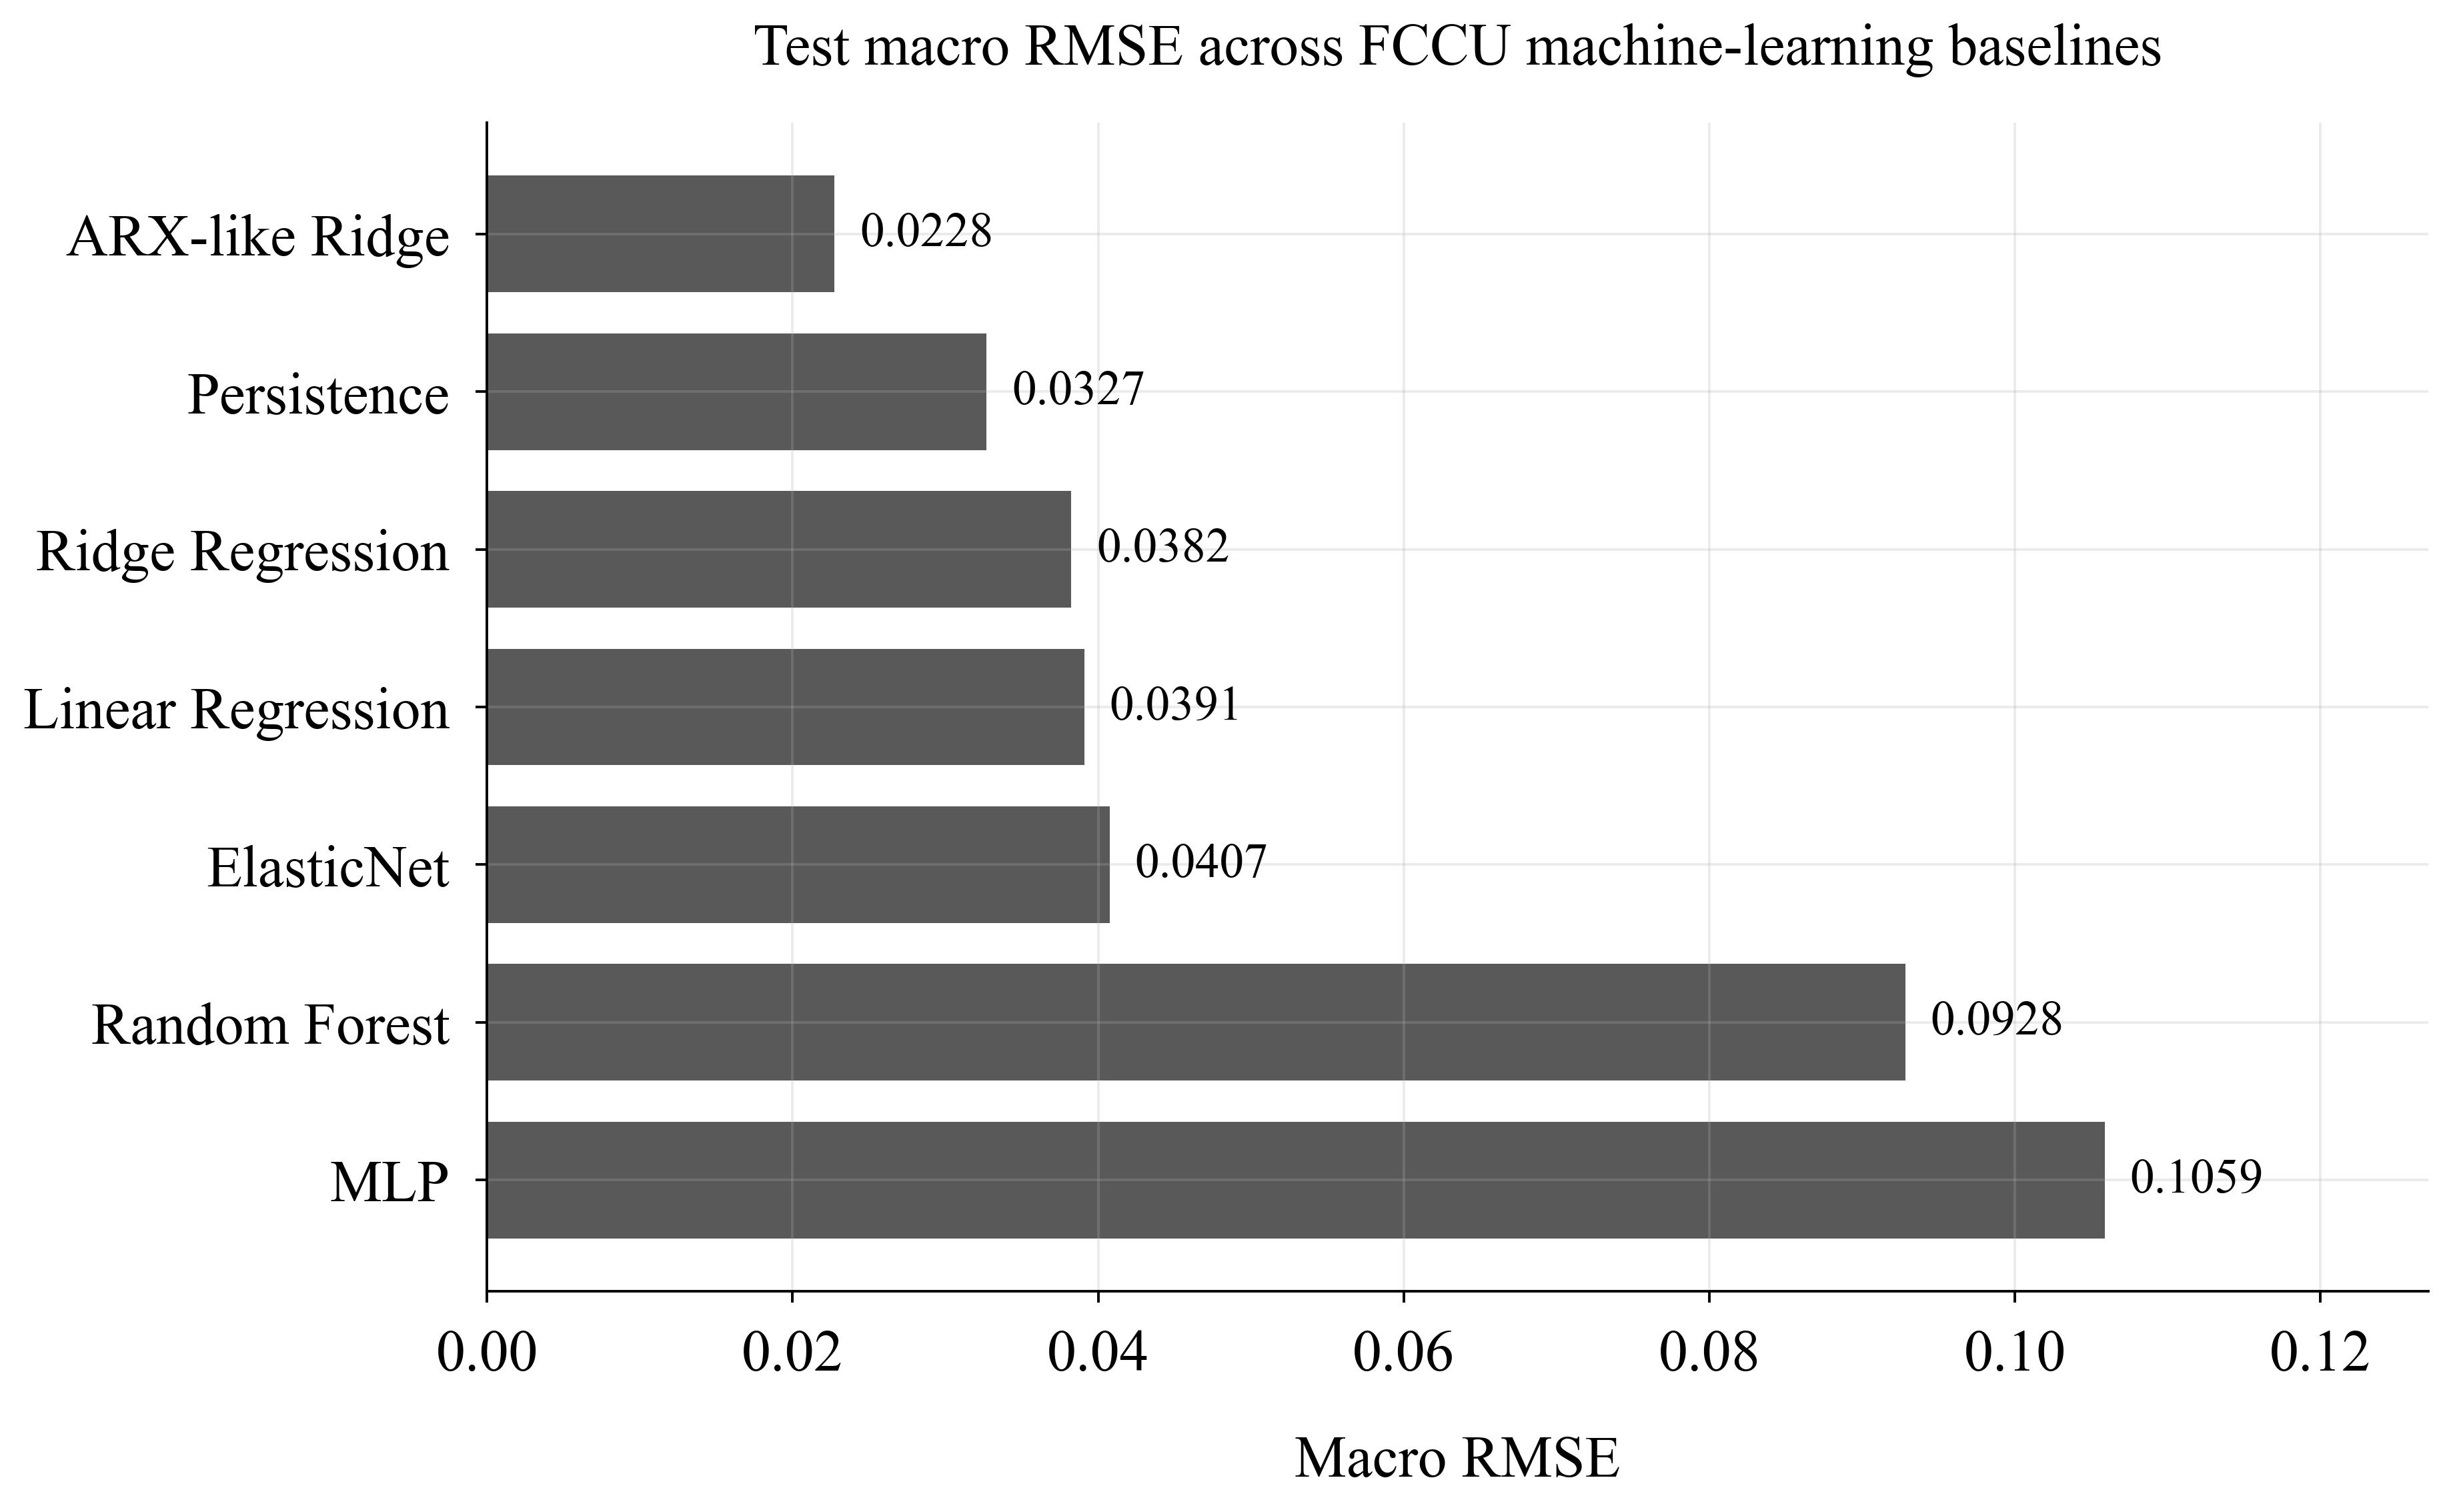

,model,group,group_value,macro_rmse,macro_mae,macro_r2,n_windows
0,Ridge Regression,condition,faulty,0.059212,0.043501,0.919240,910
1,Ridge Regression,condition,normal,0.020014,0.016004,0.975664,1876
2,Ridge Regression,phase_group,normal,0.020014,0.016004,0.975664,1876
3,Ridge Regression,phase_group,post_transition,0.040539,0.031029,0.924783,728
4,Ridge Regression,phase_group,transition,0.096845,0.093389,0.465573,182
5,ARX-like Ridge,condition,faulty,0.028941,0.022479,0.926207,910
6,ARX-like Ridge,condition,normal,0.018696,0.014927,0.976511,1876
7,ARX-like Ridge,phase_group,normal,0.018696,0.014927,0.976511,1876
8,ARX-like Ridge,phase_group,post_transition,0.030093,0.023492,0.927651,728
9,ARX-like Ridge,phase_group,transition,0.023448,0.018430,0.902228,182


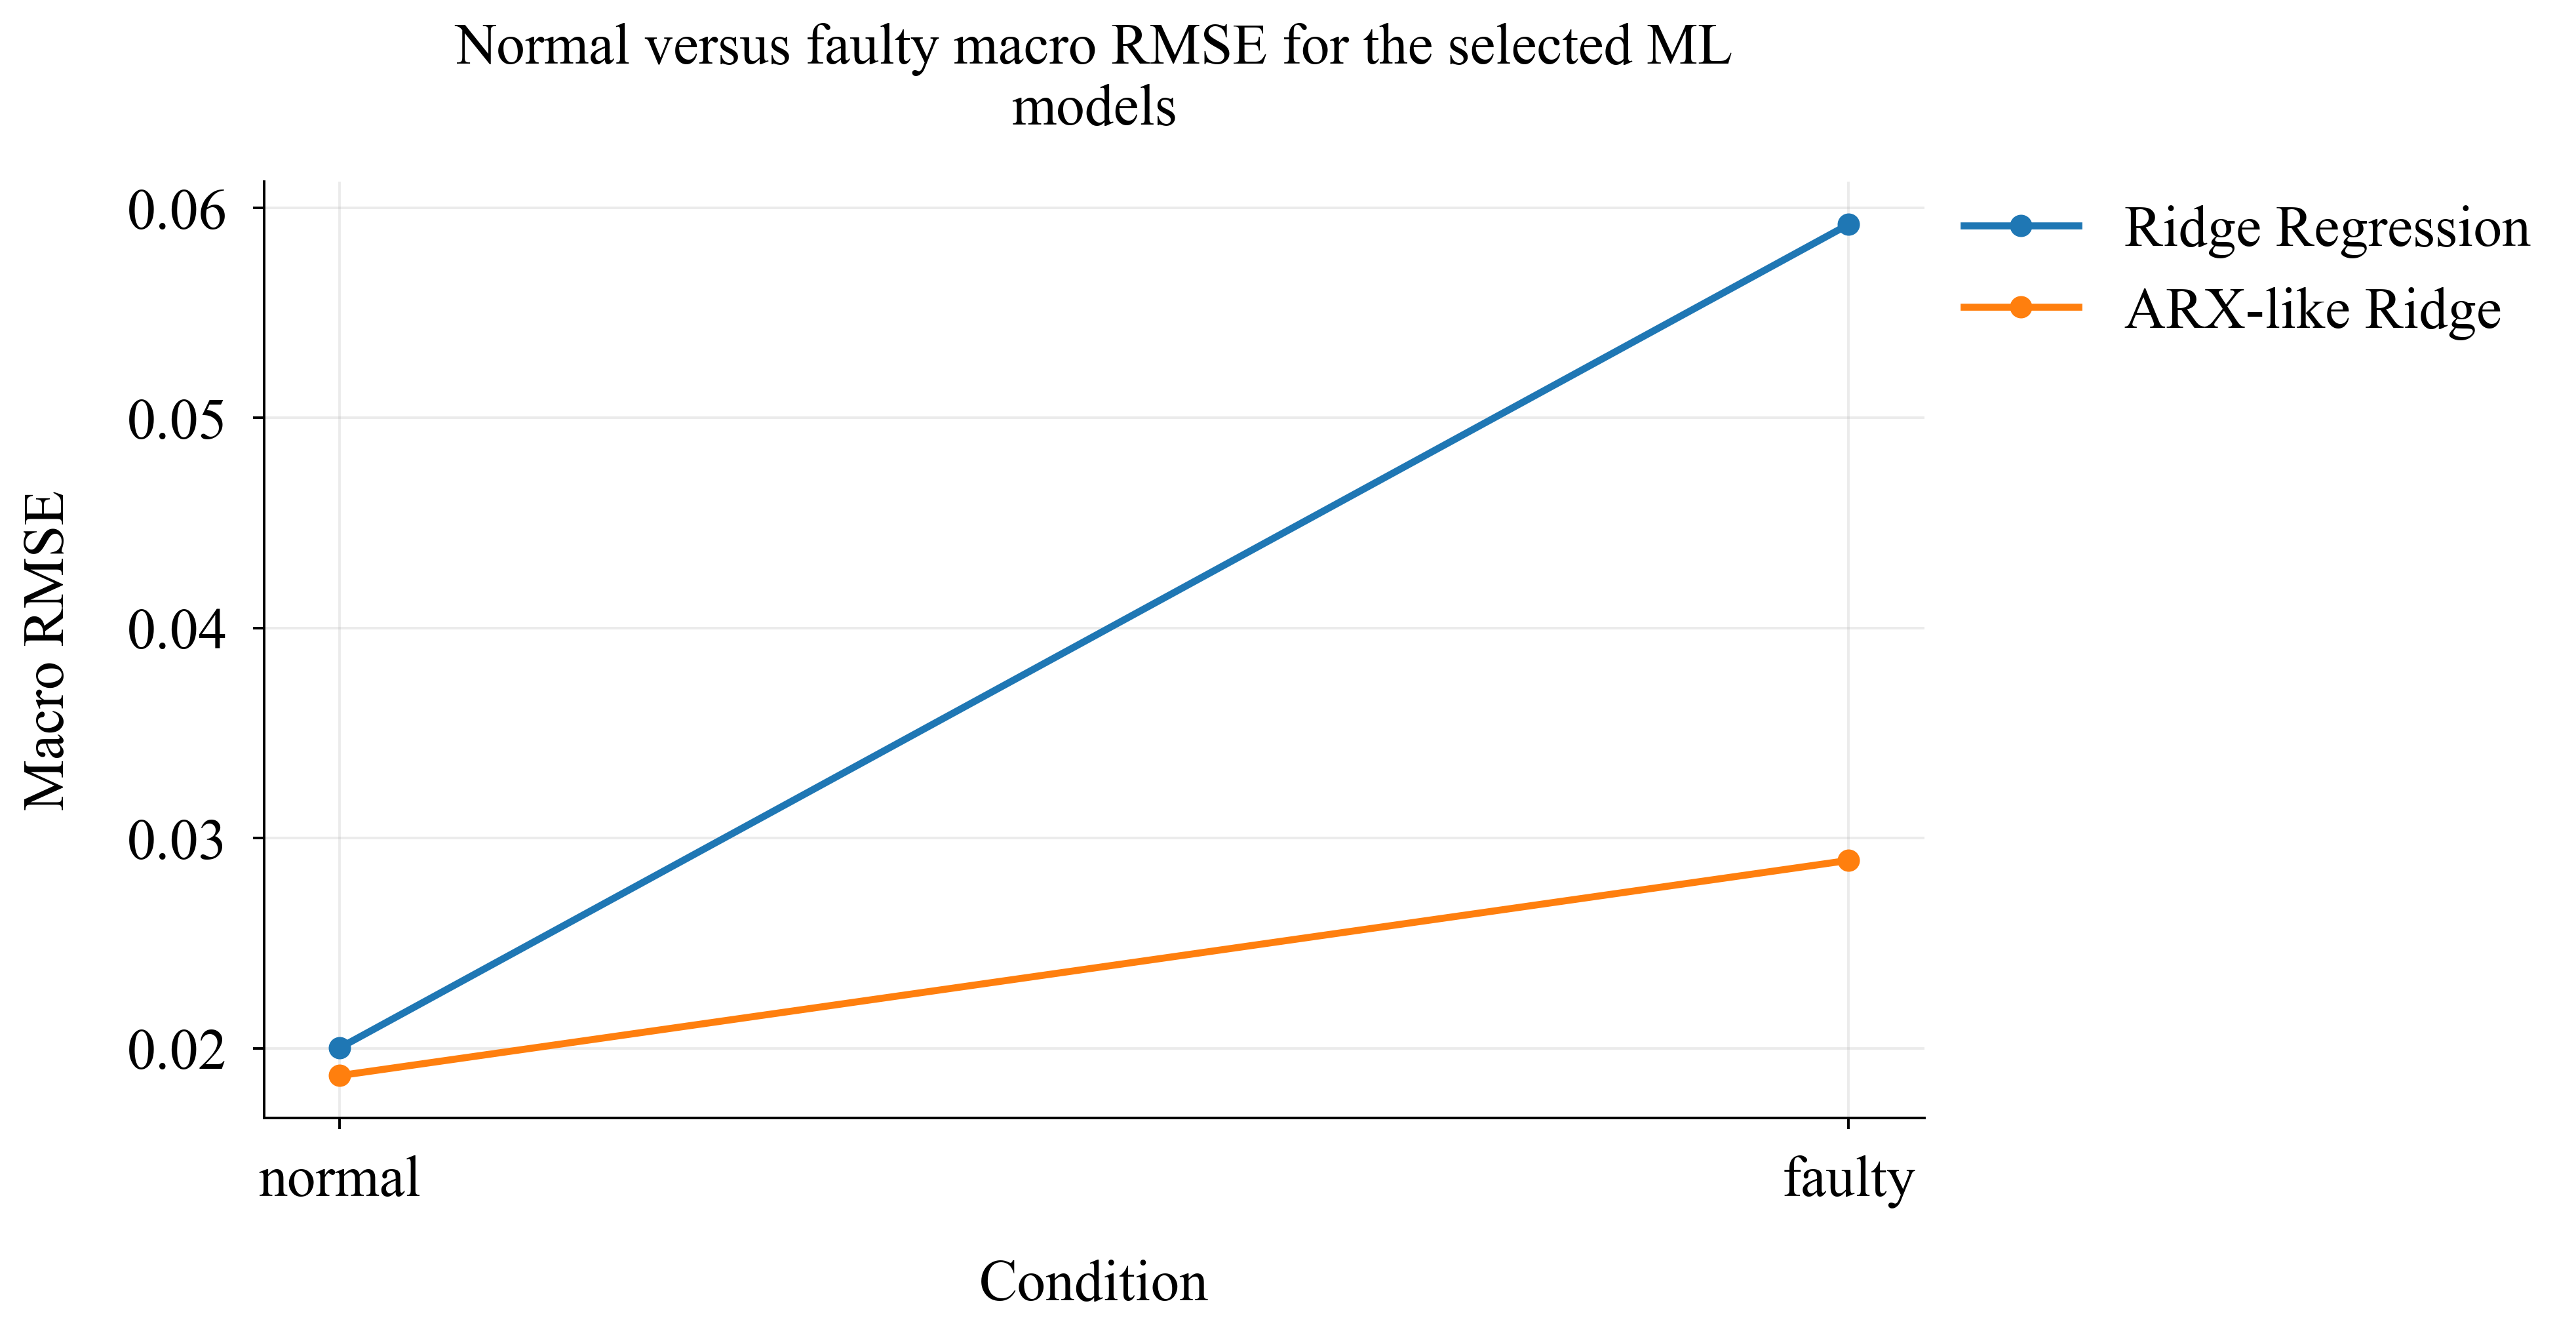

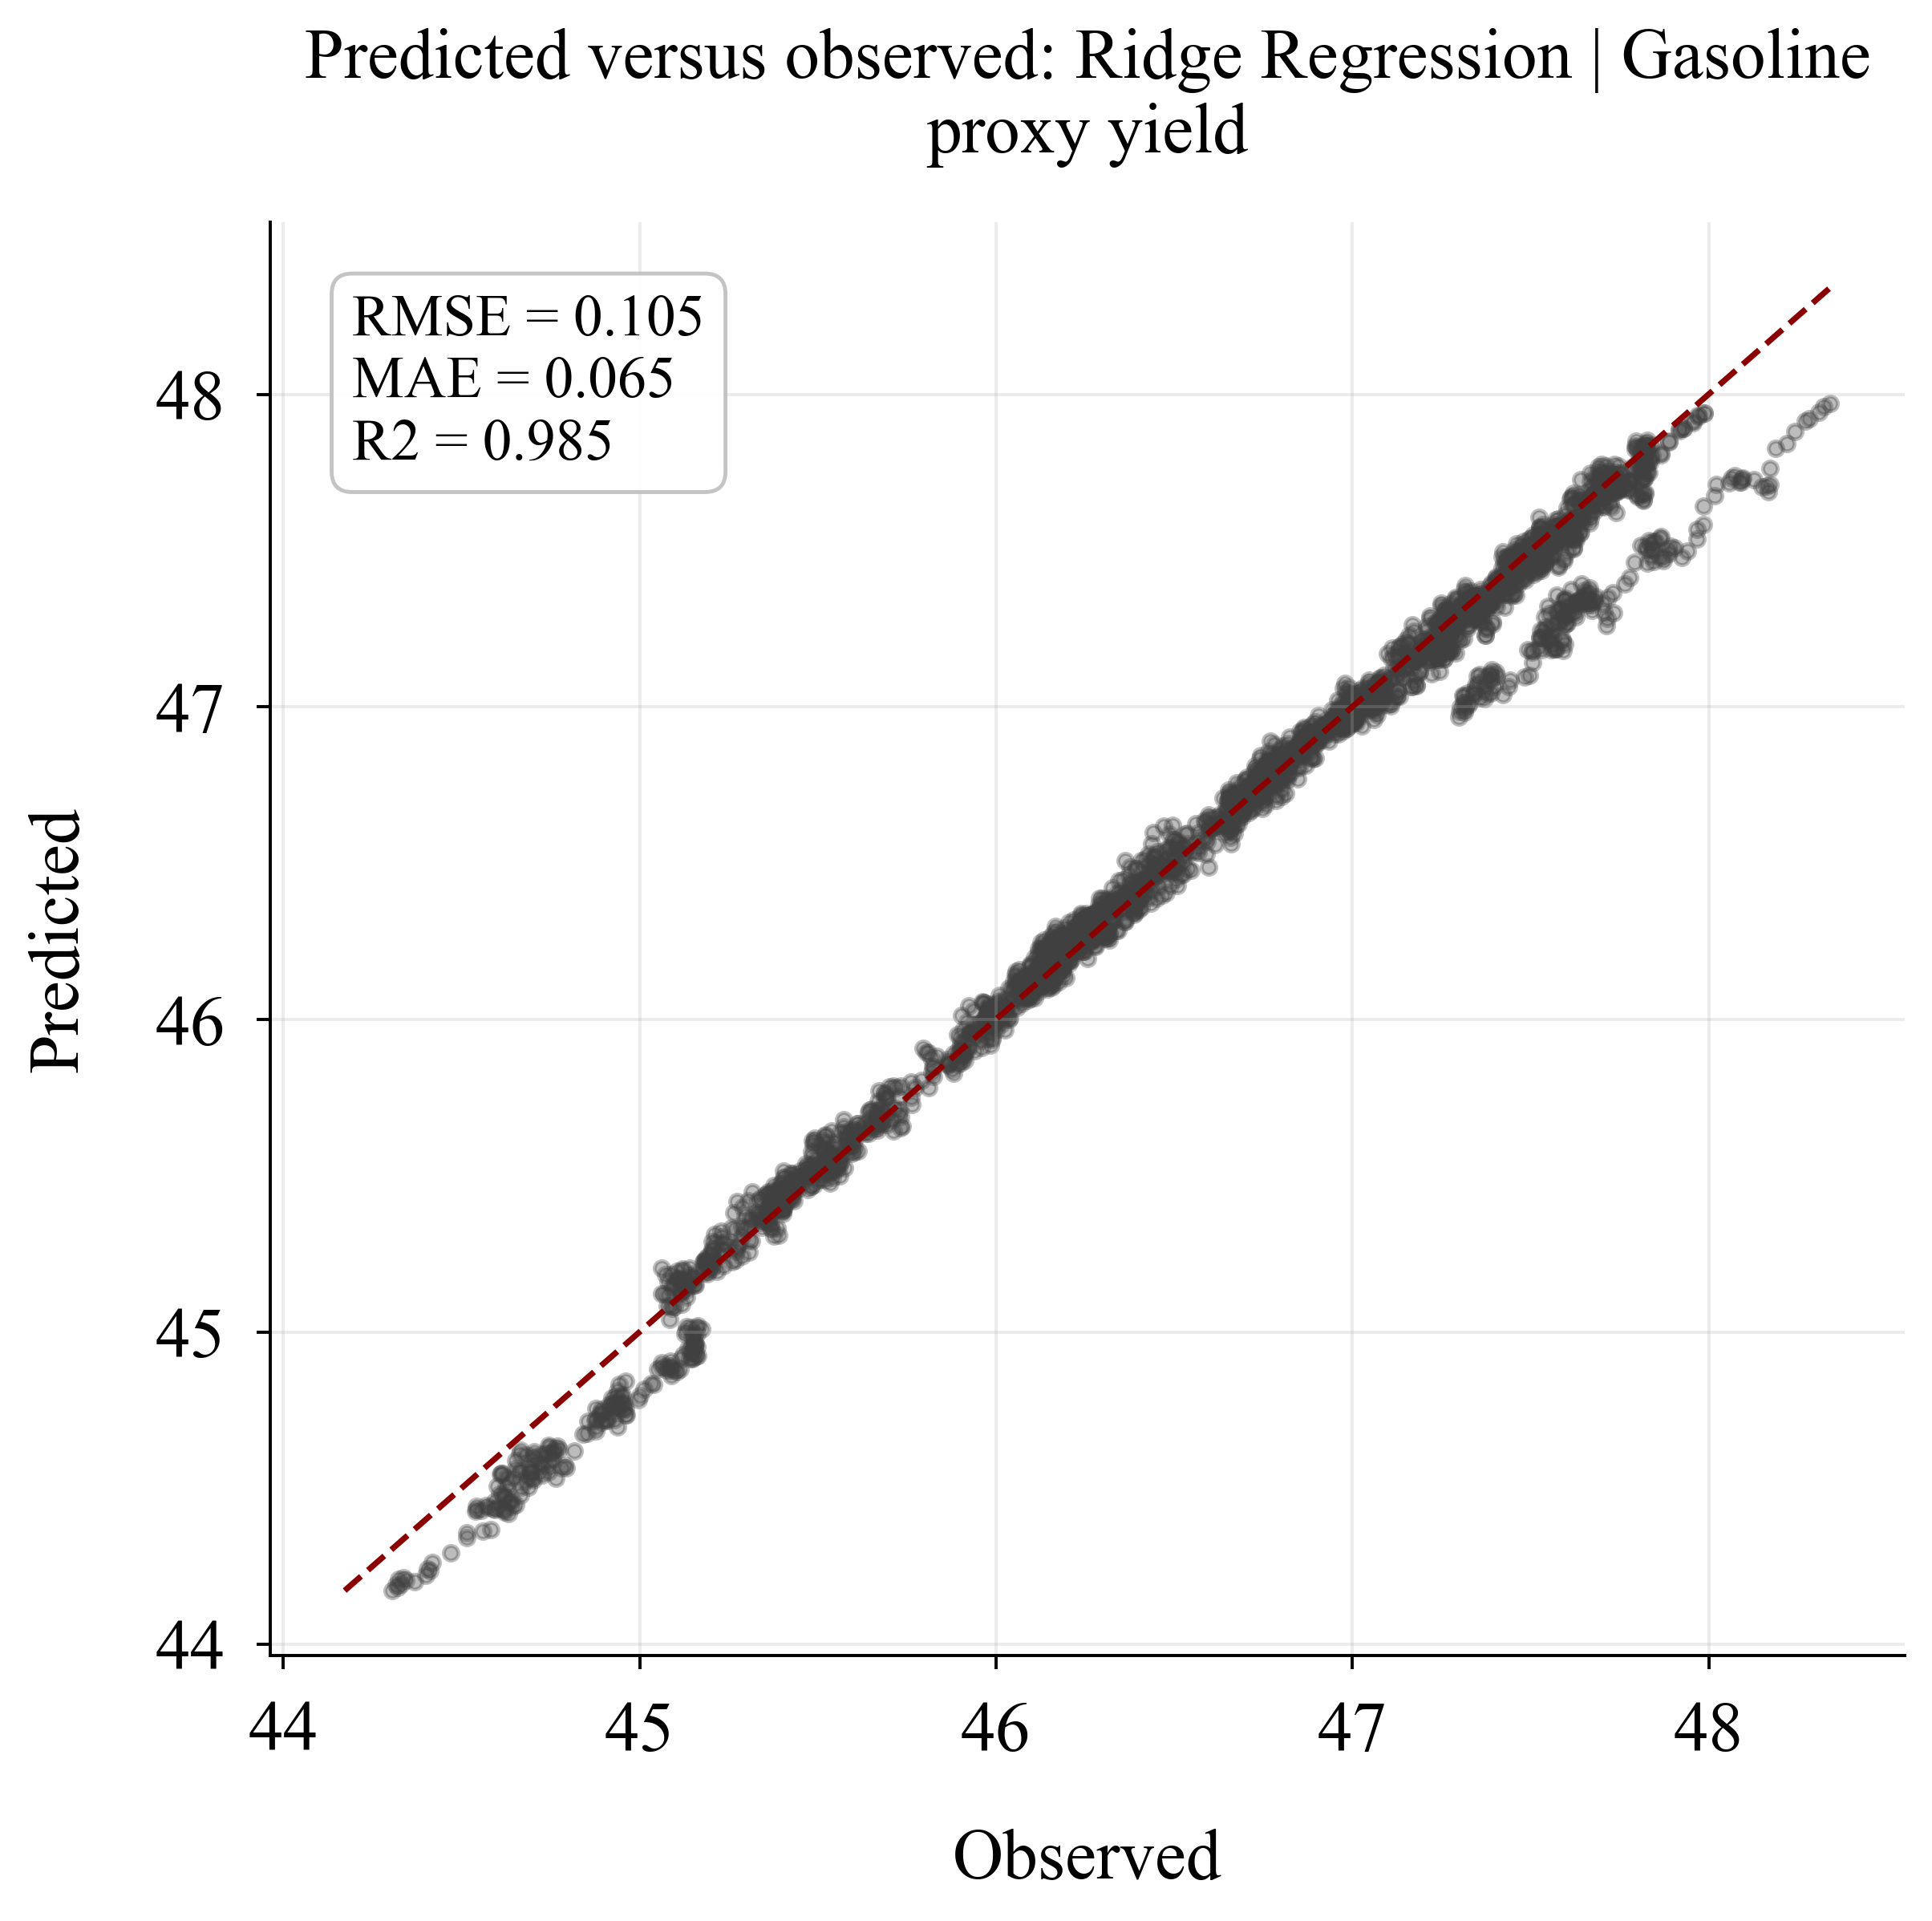

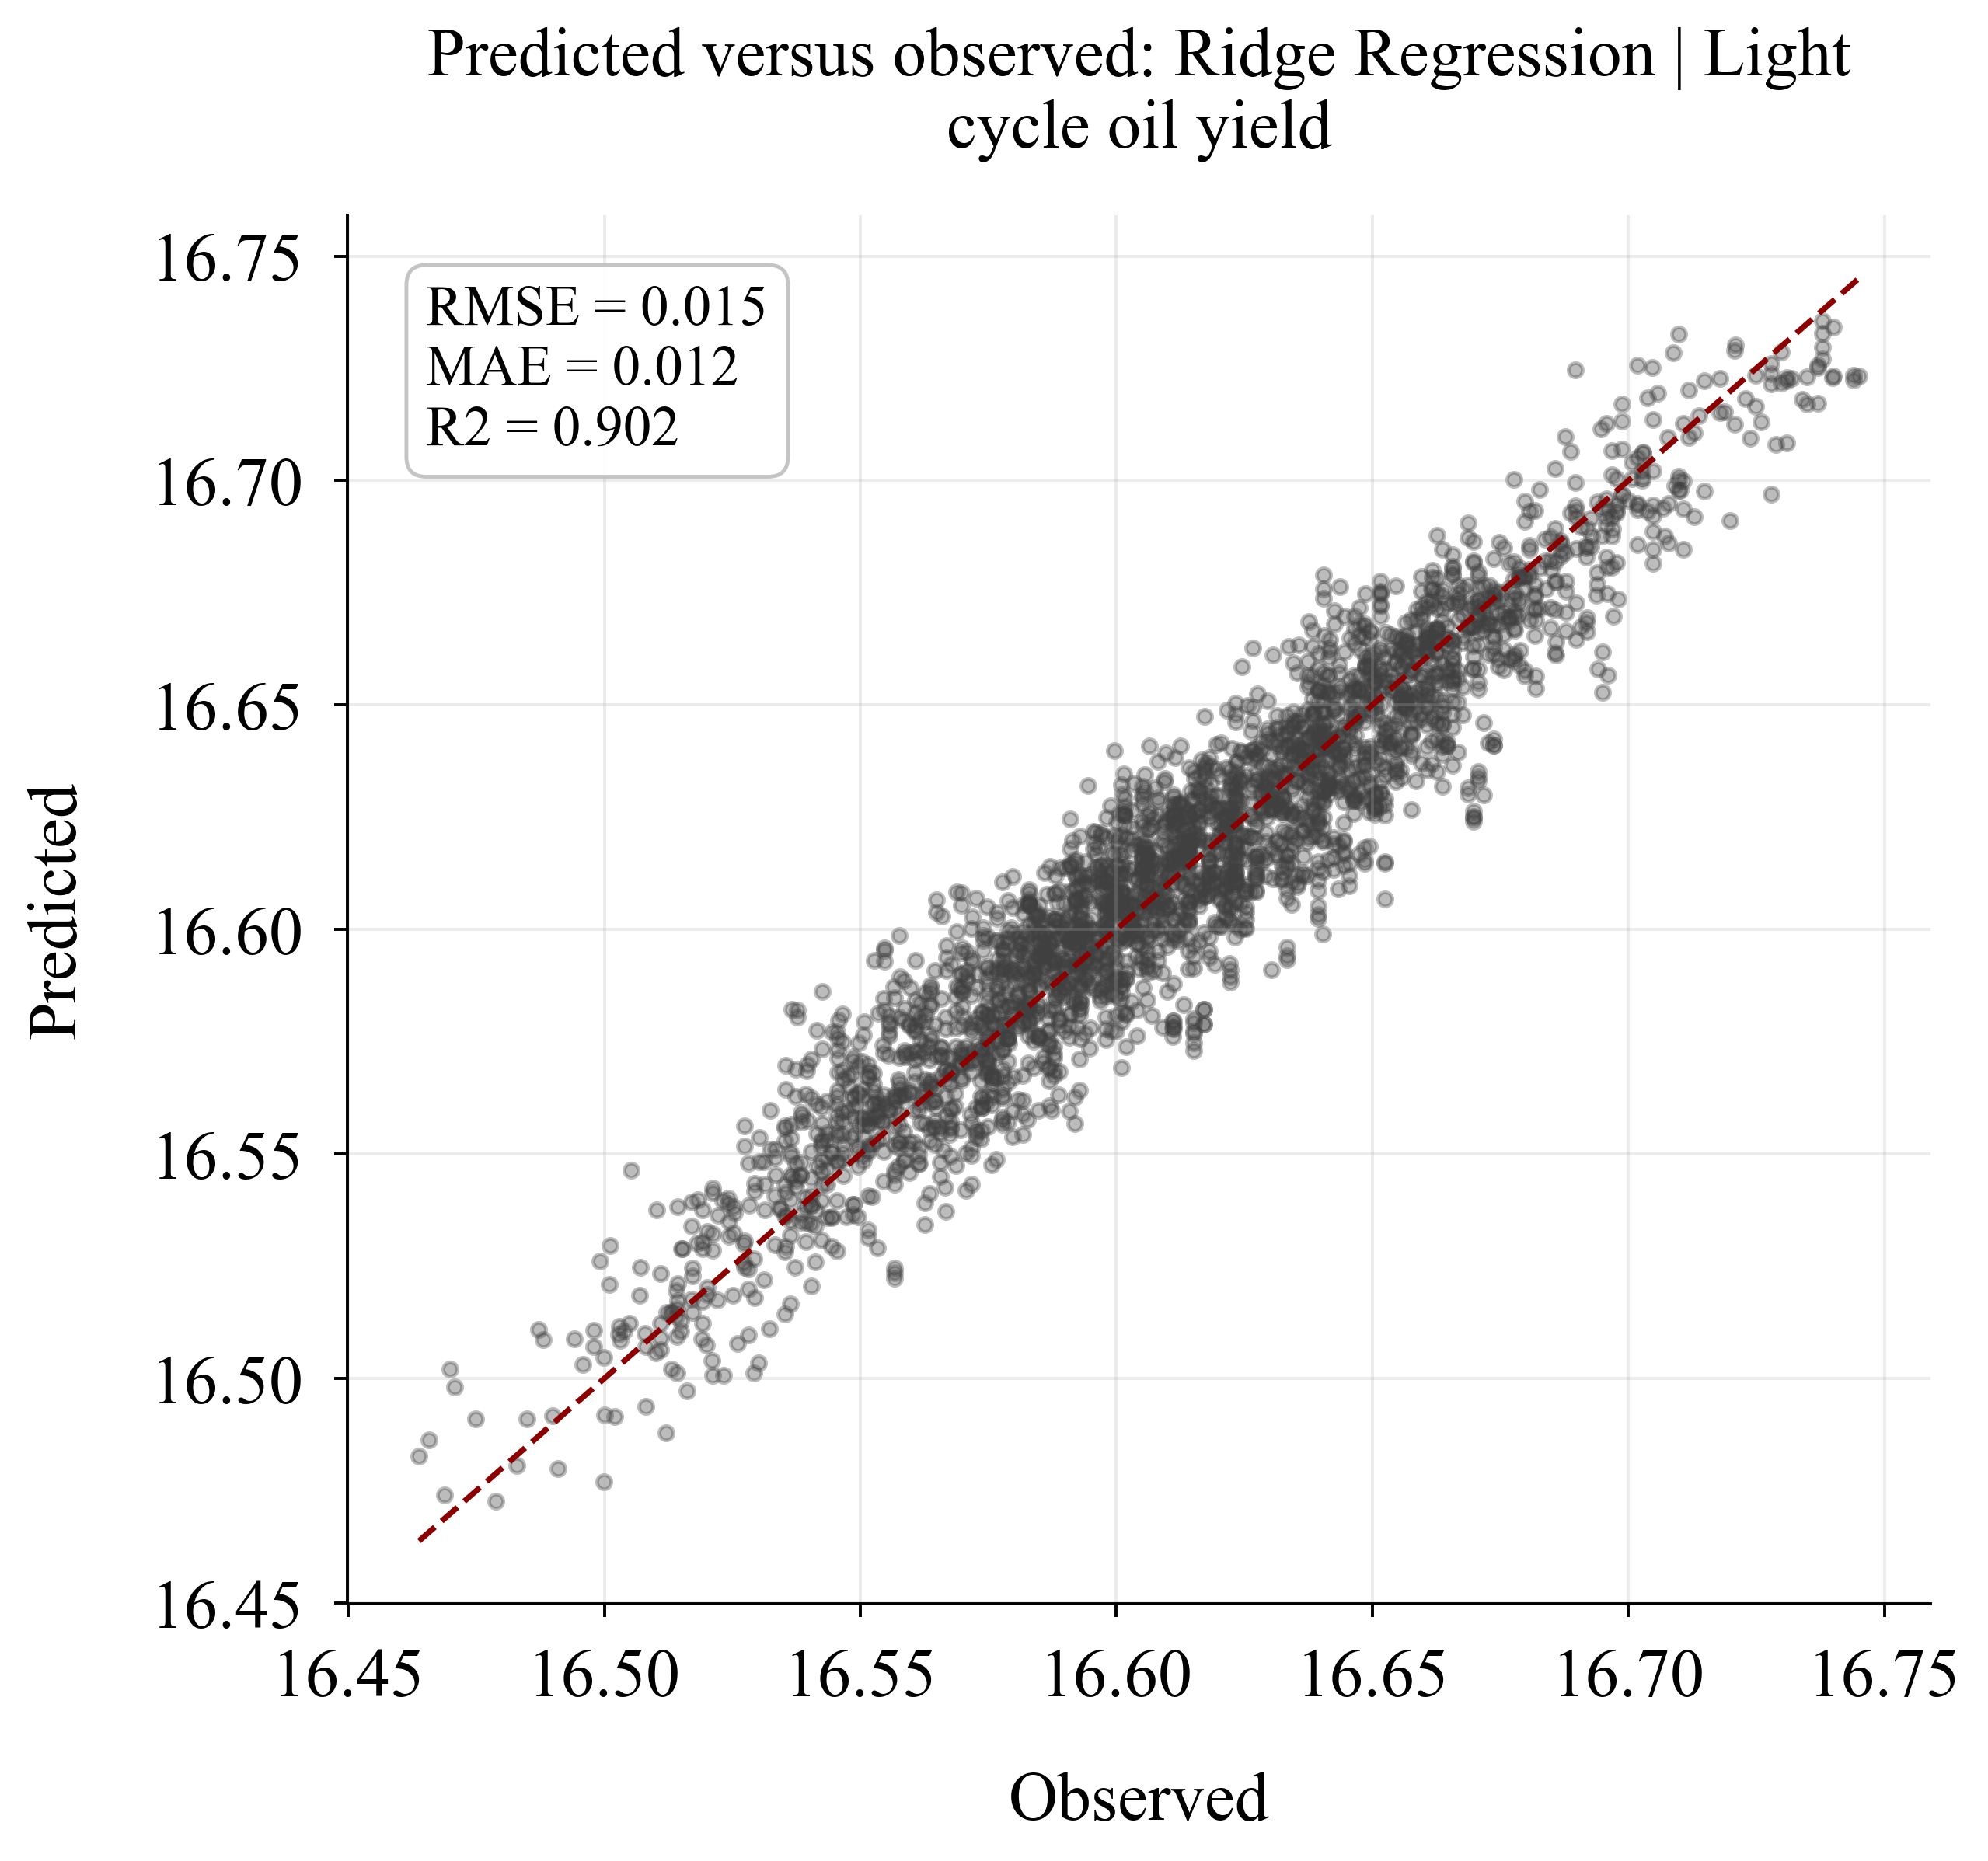

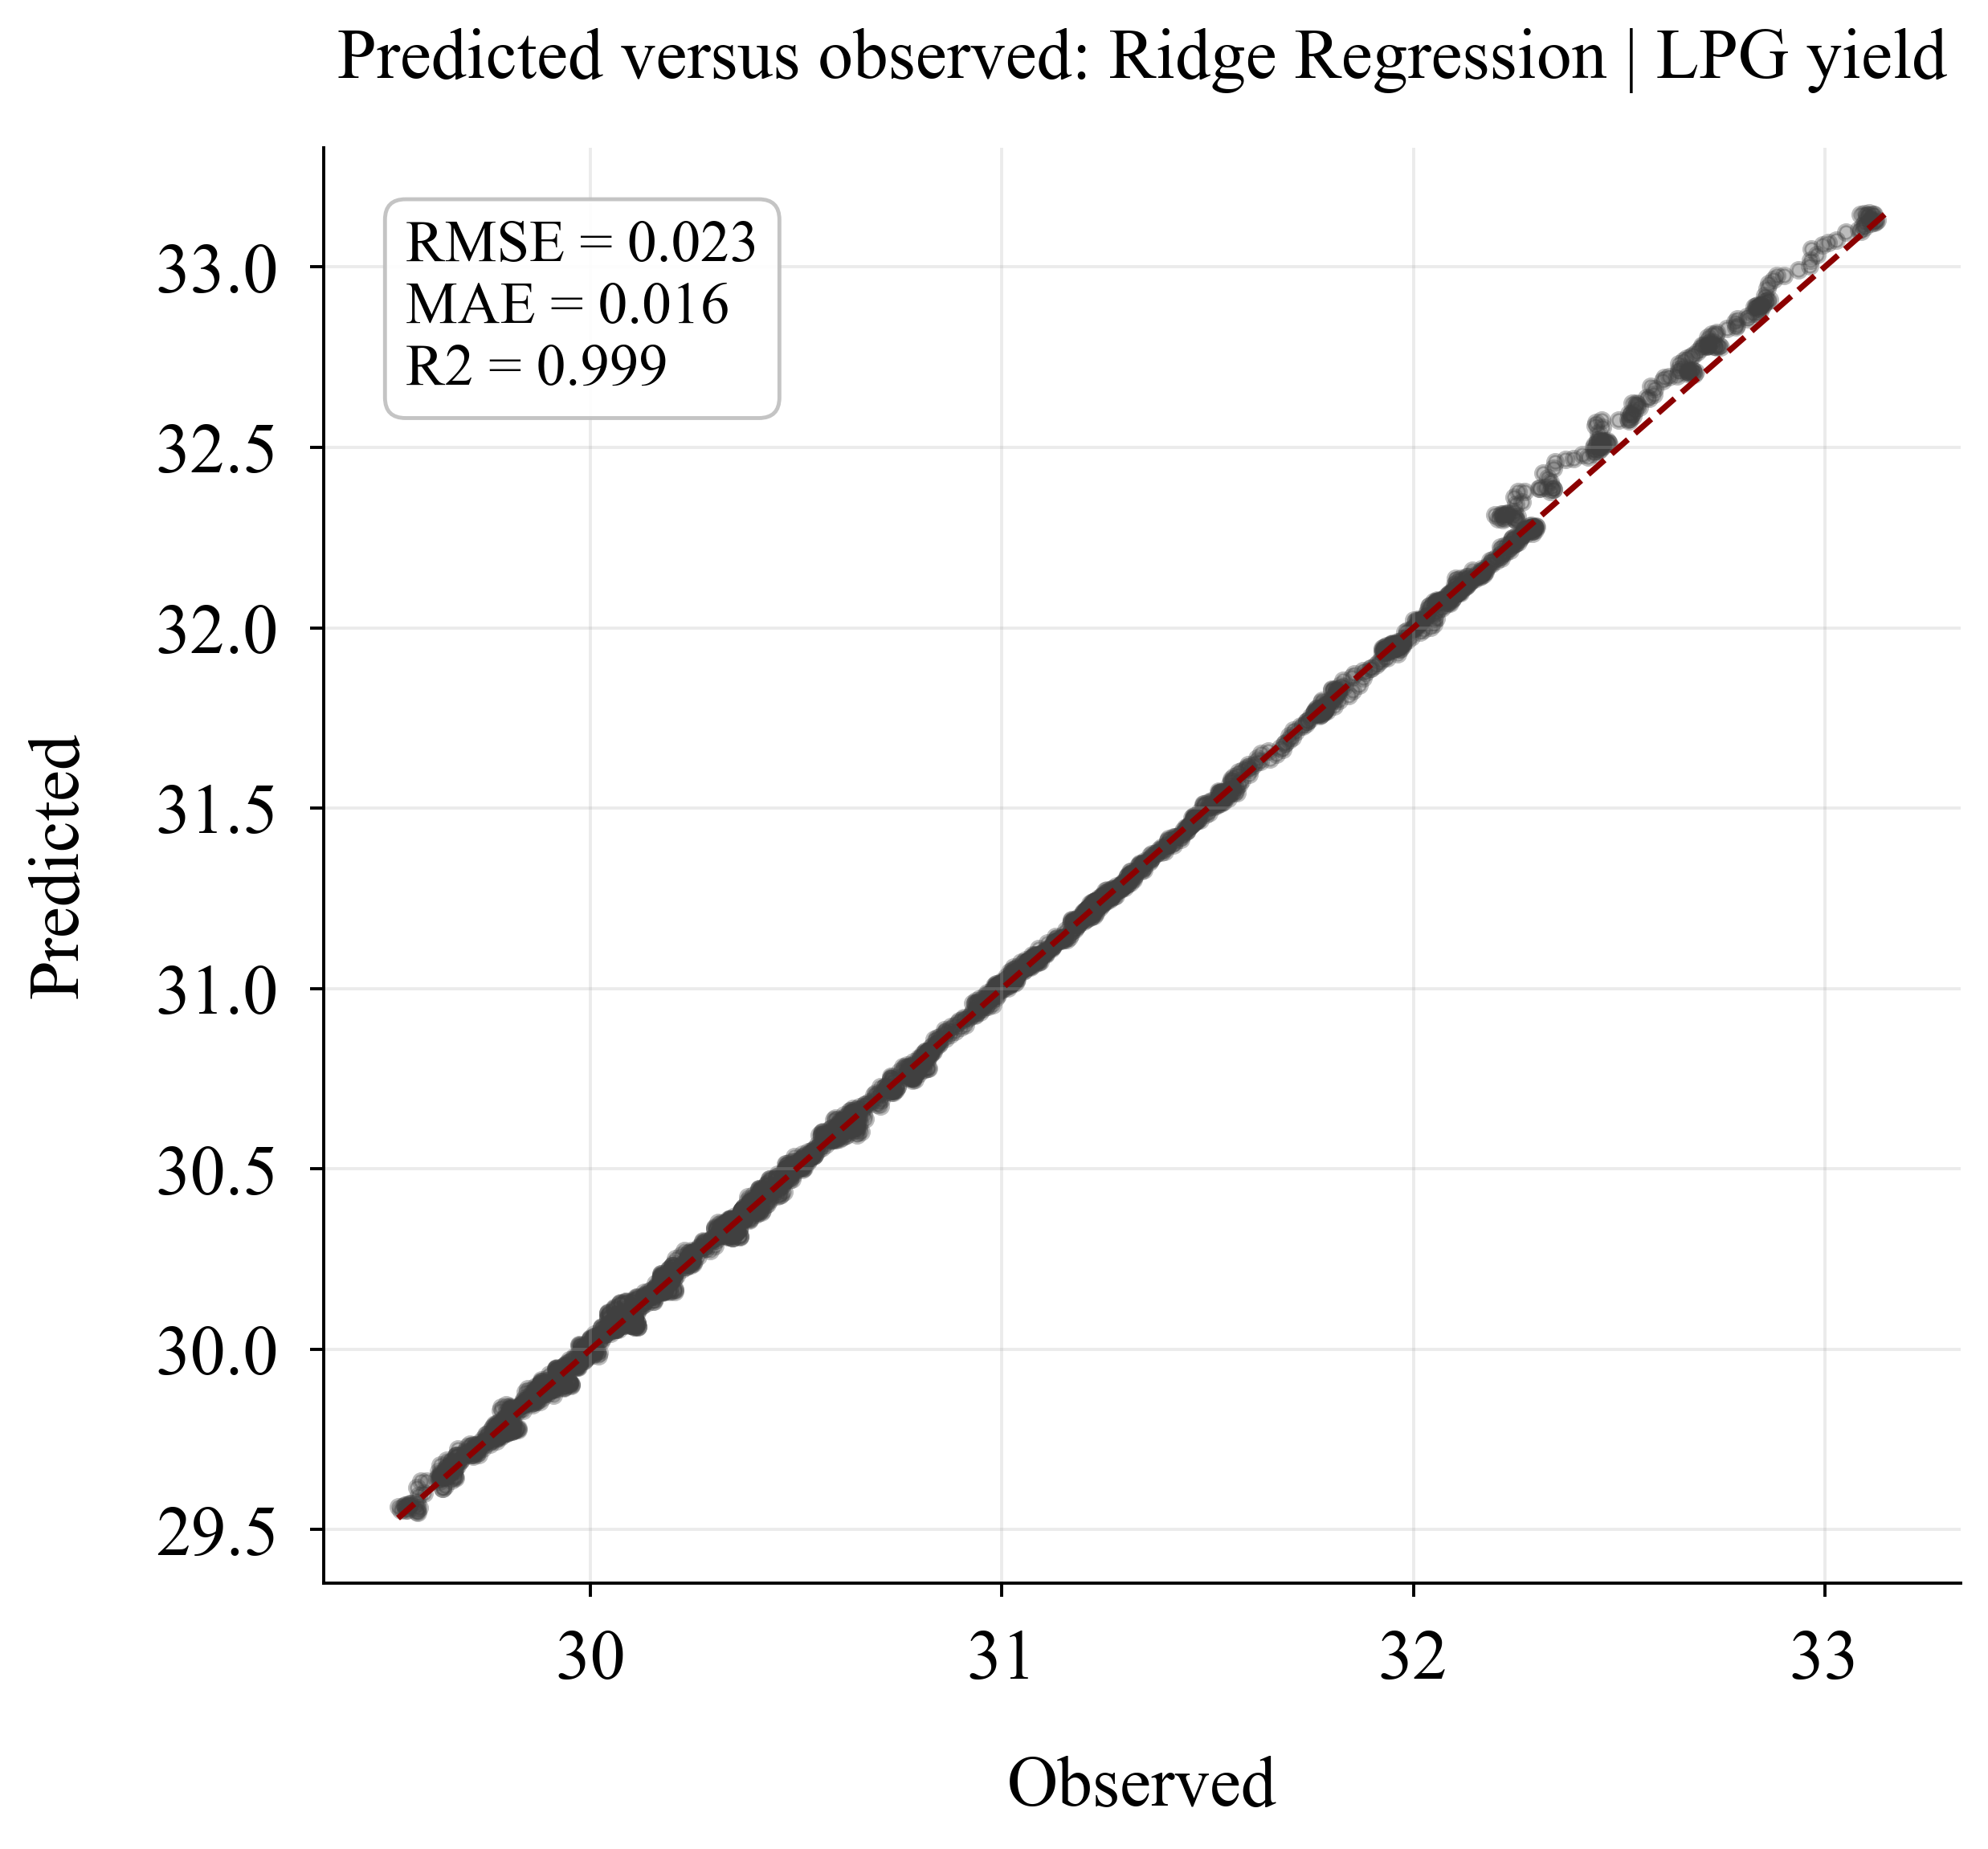

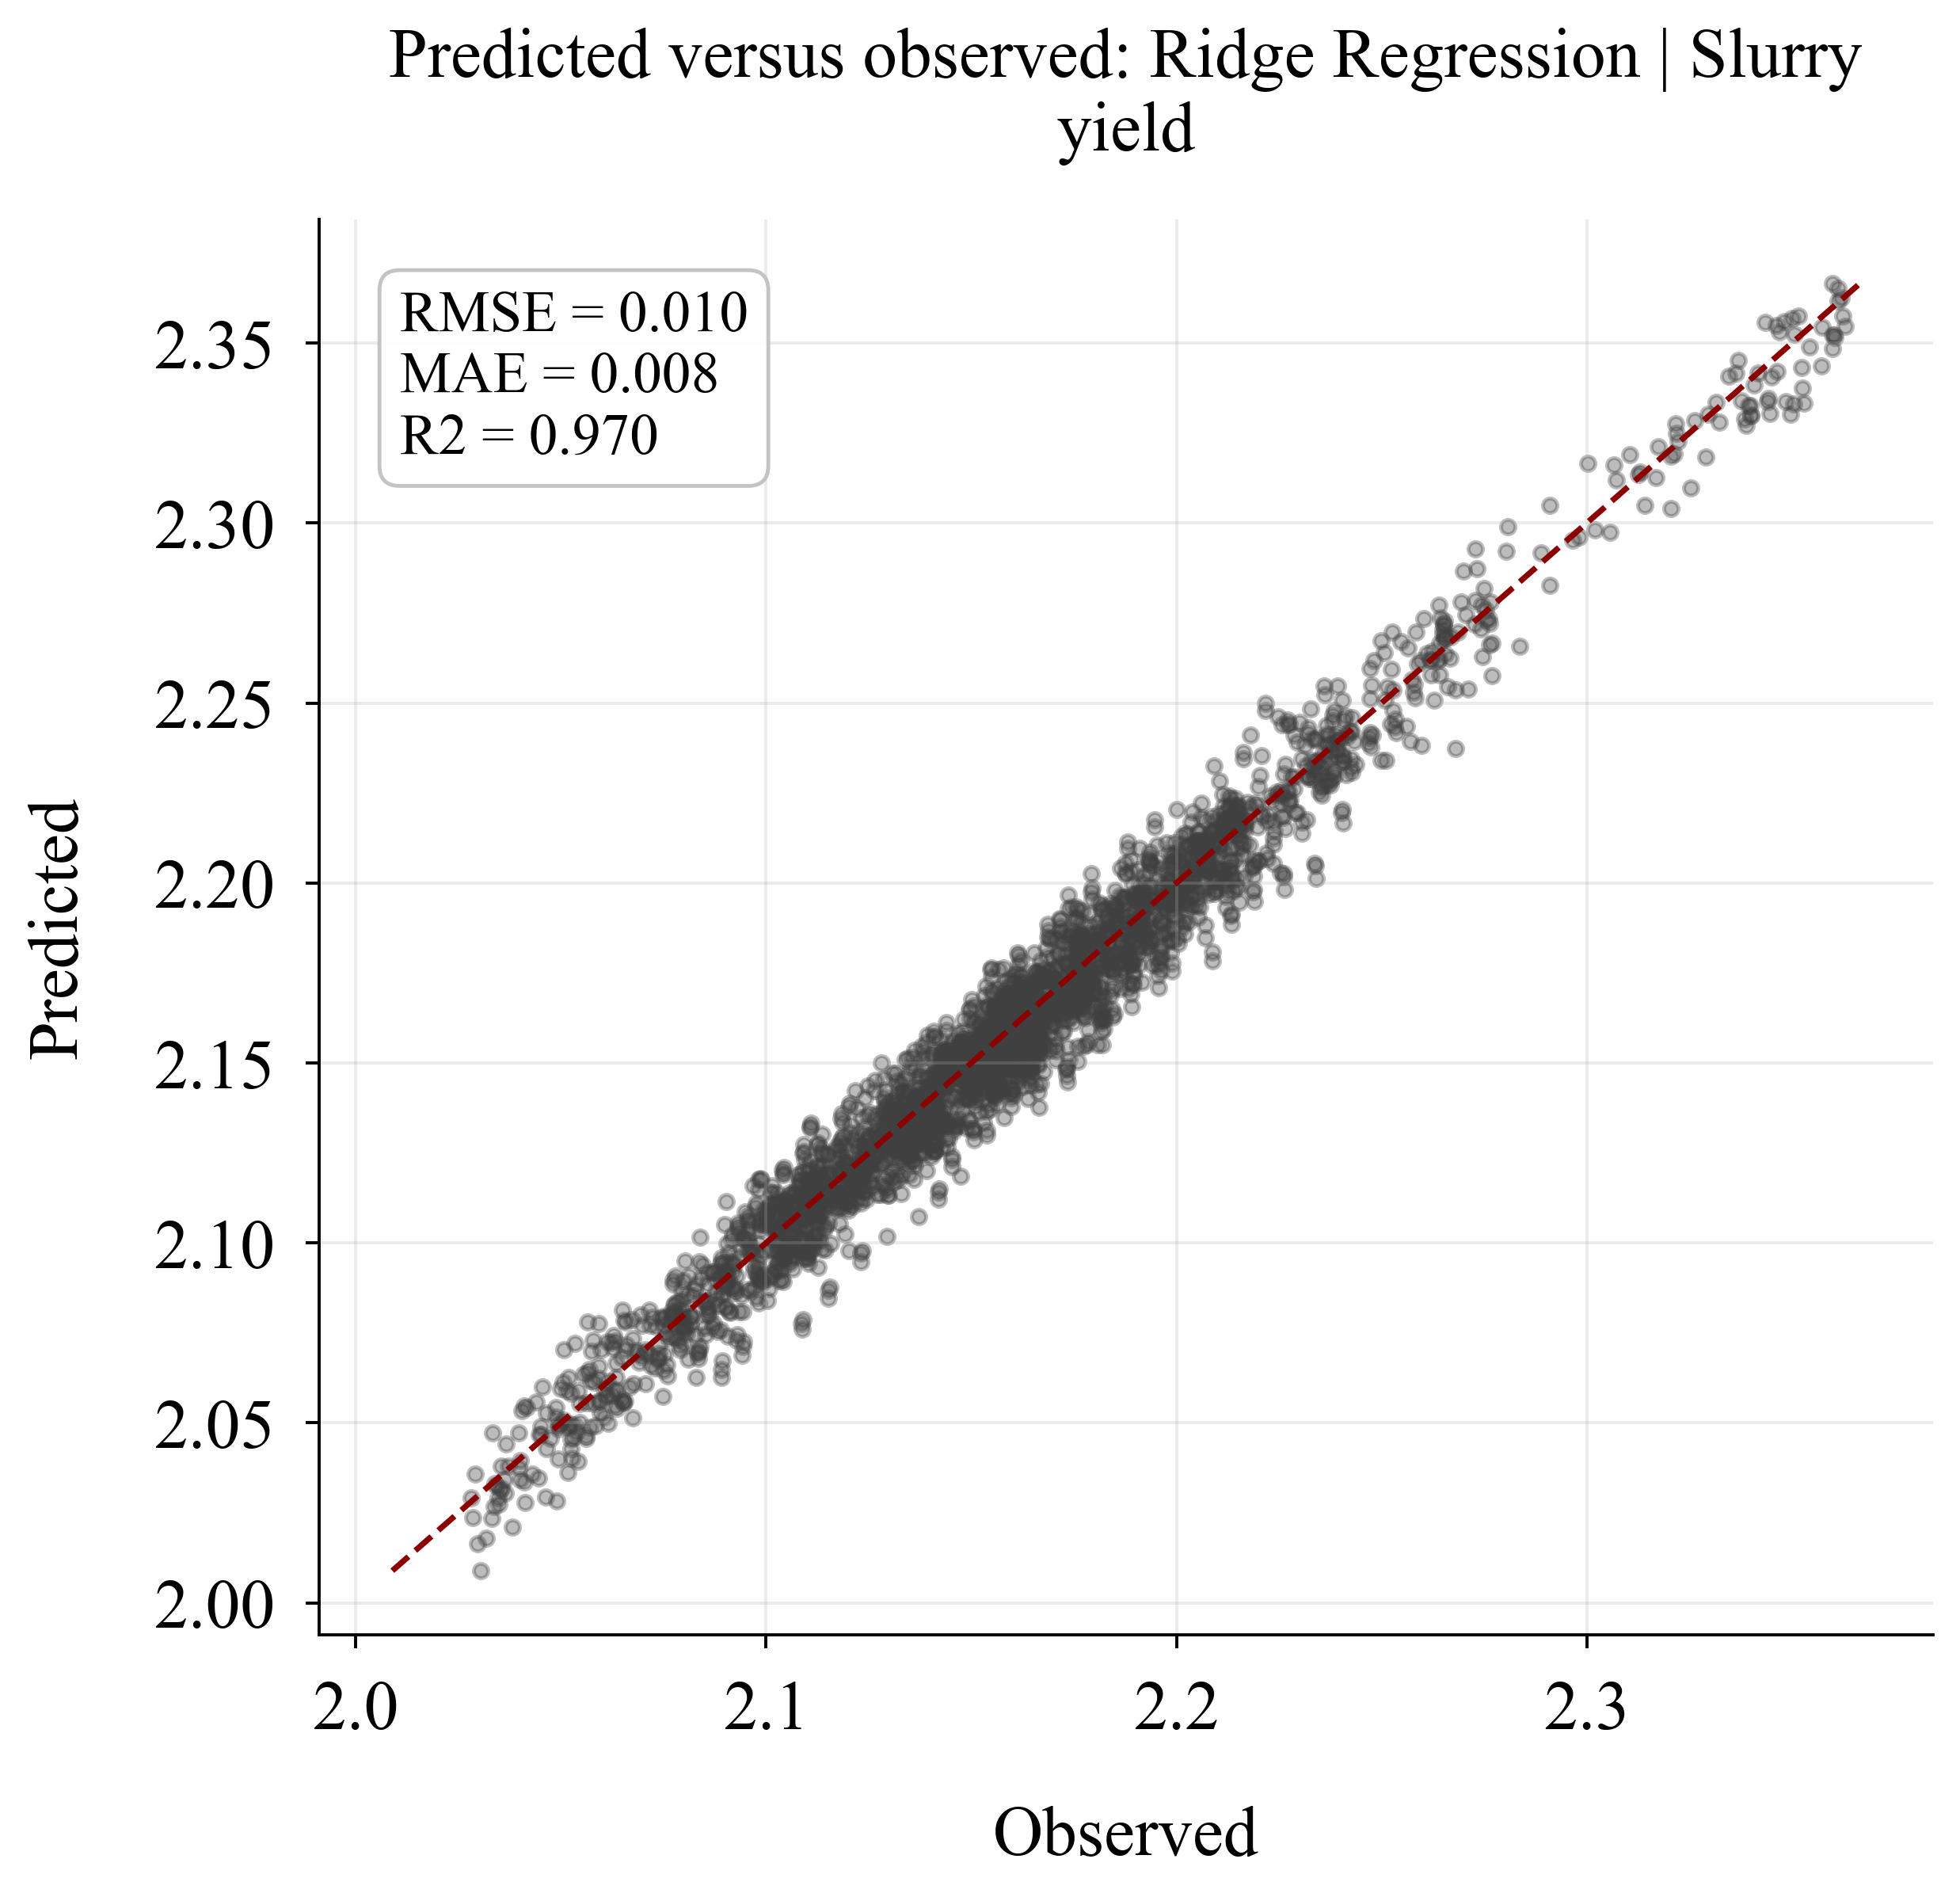

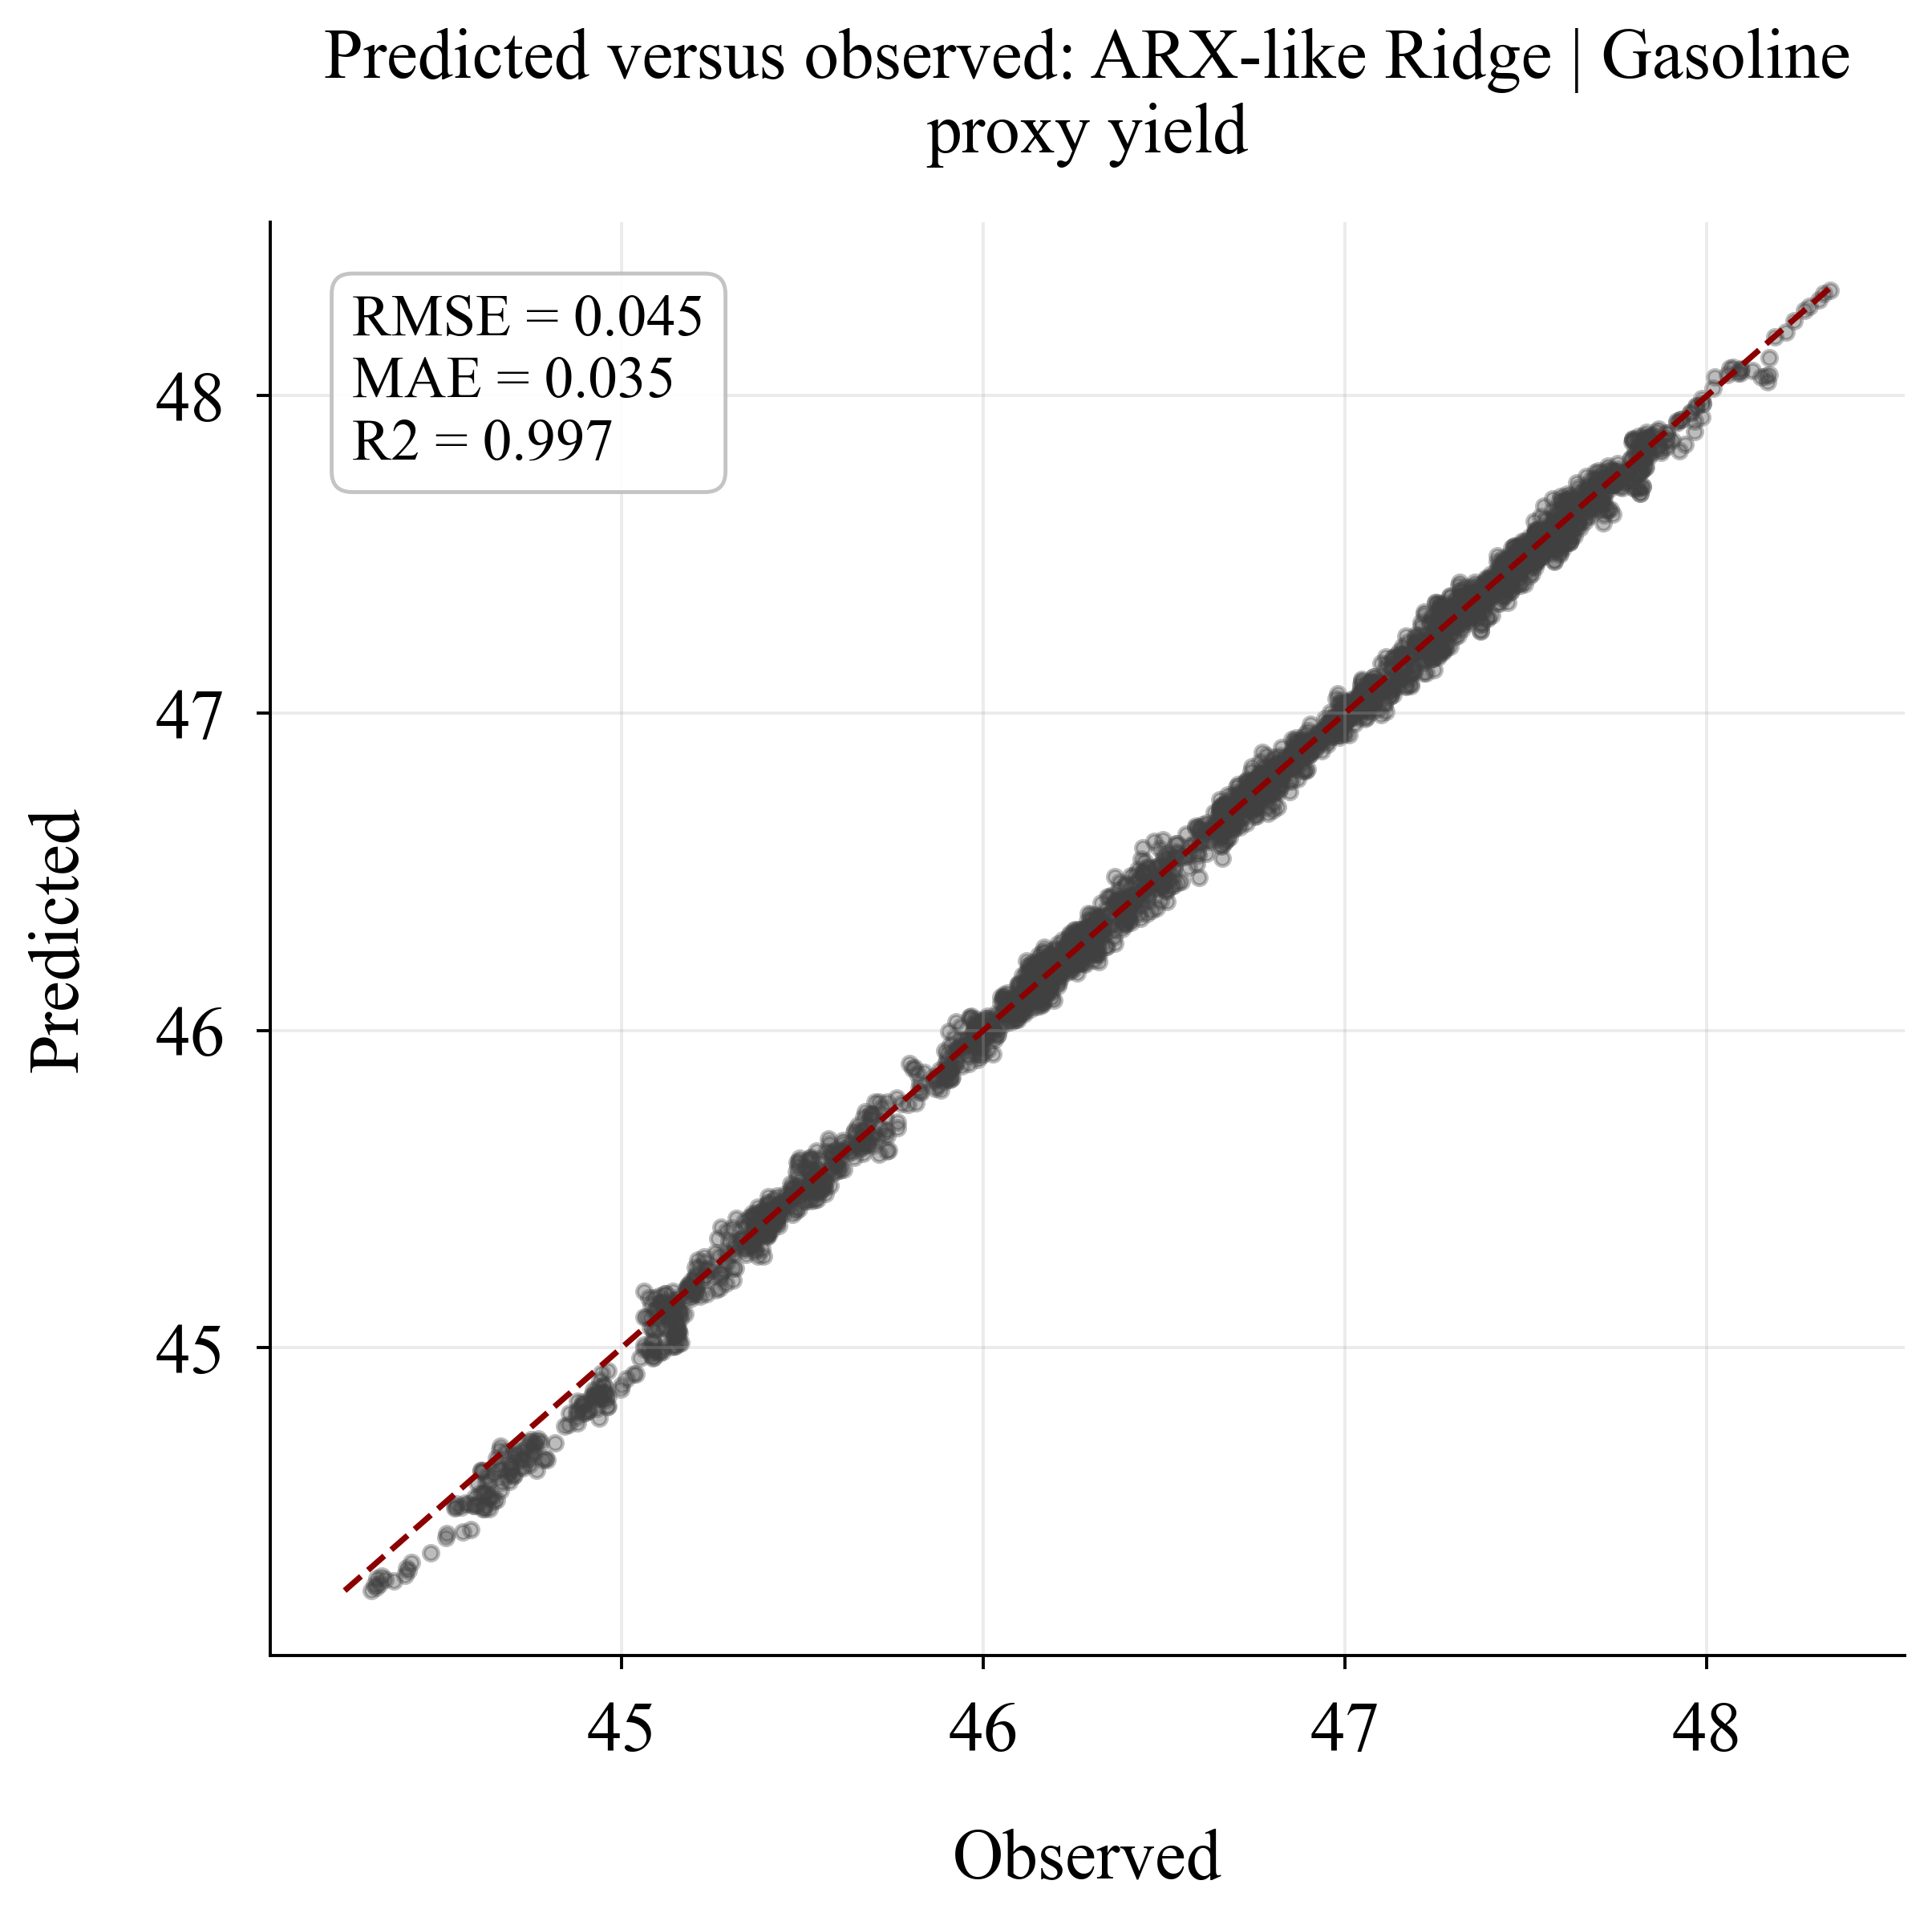

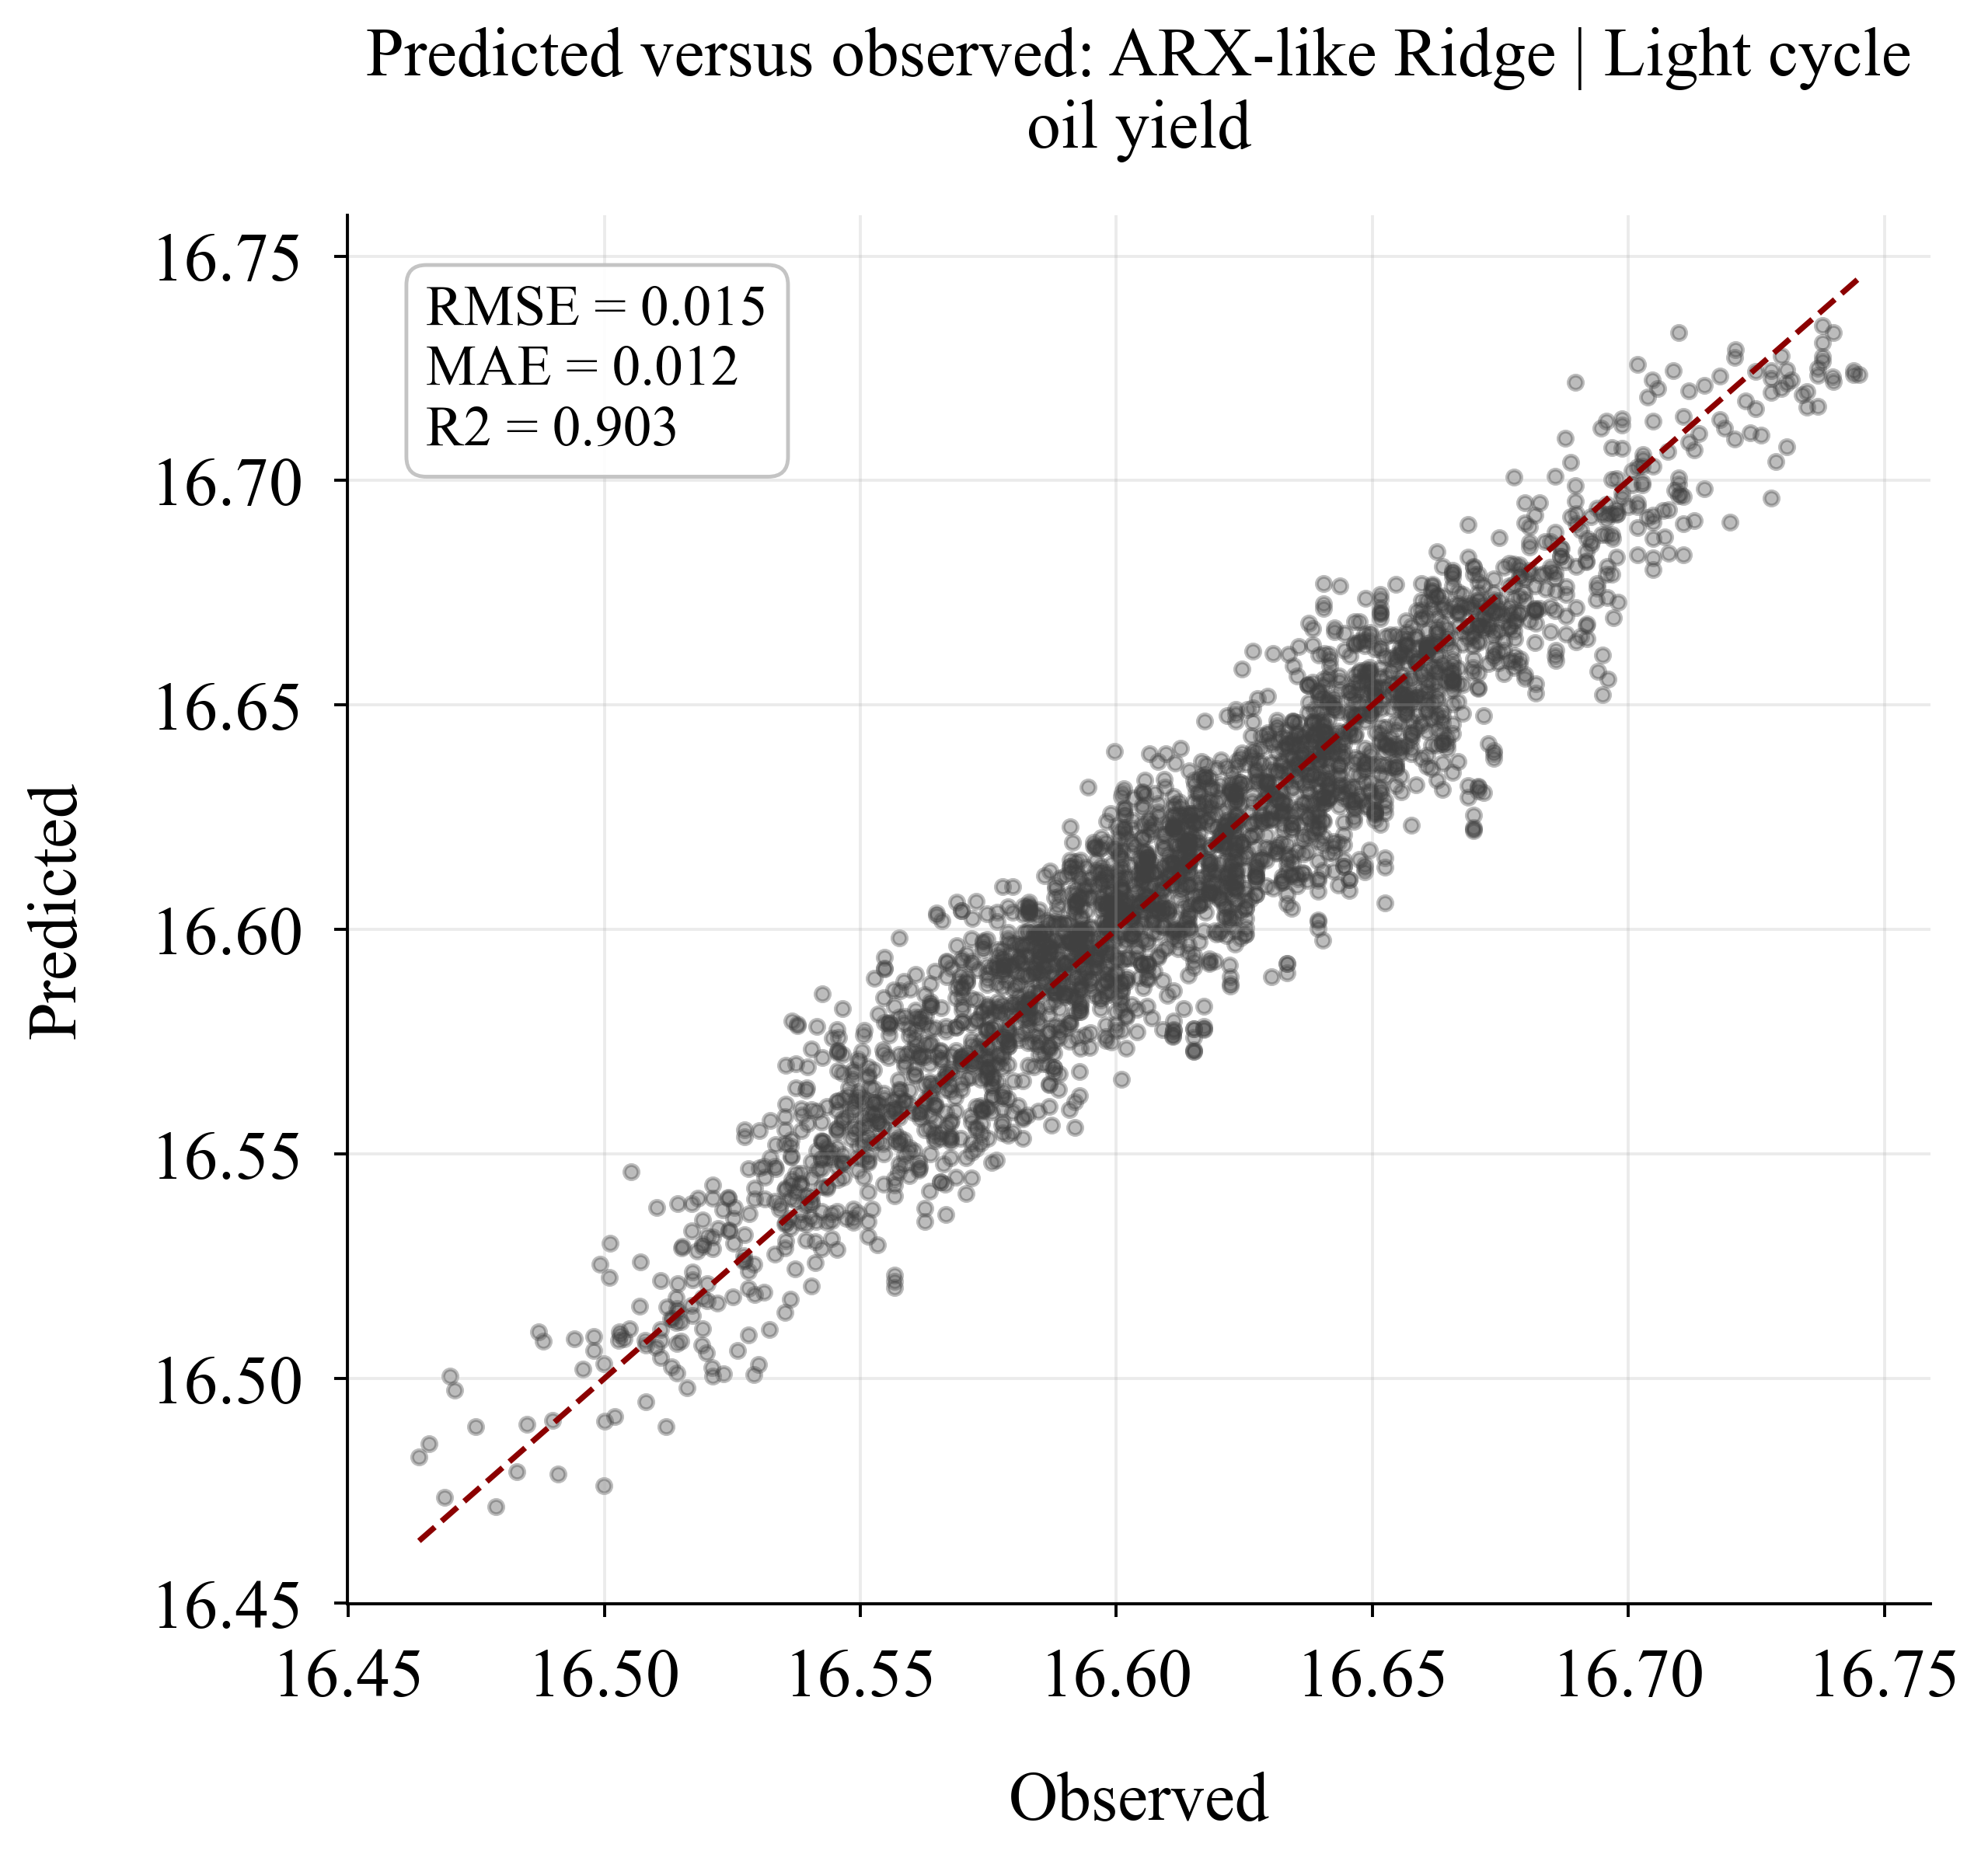

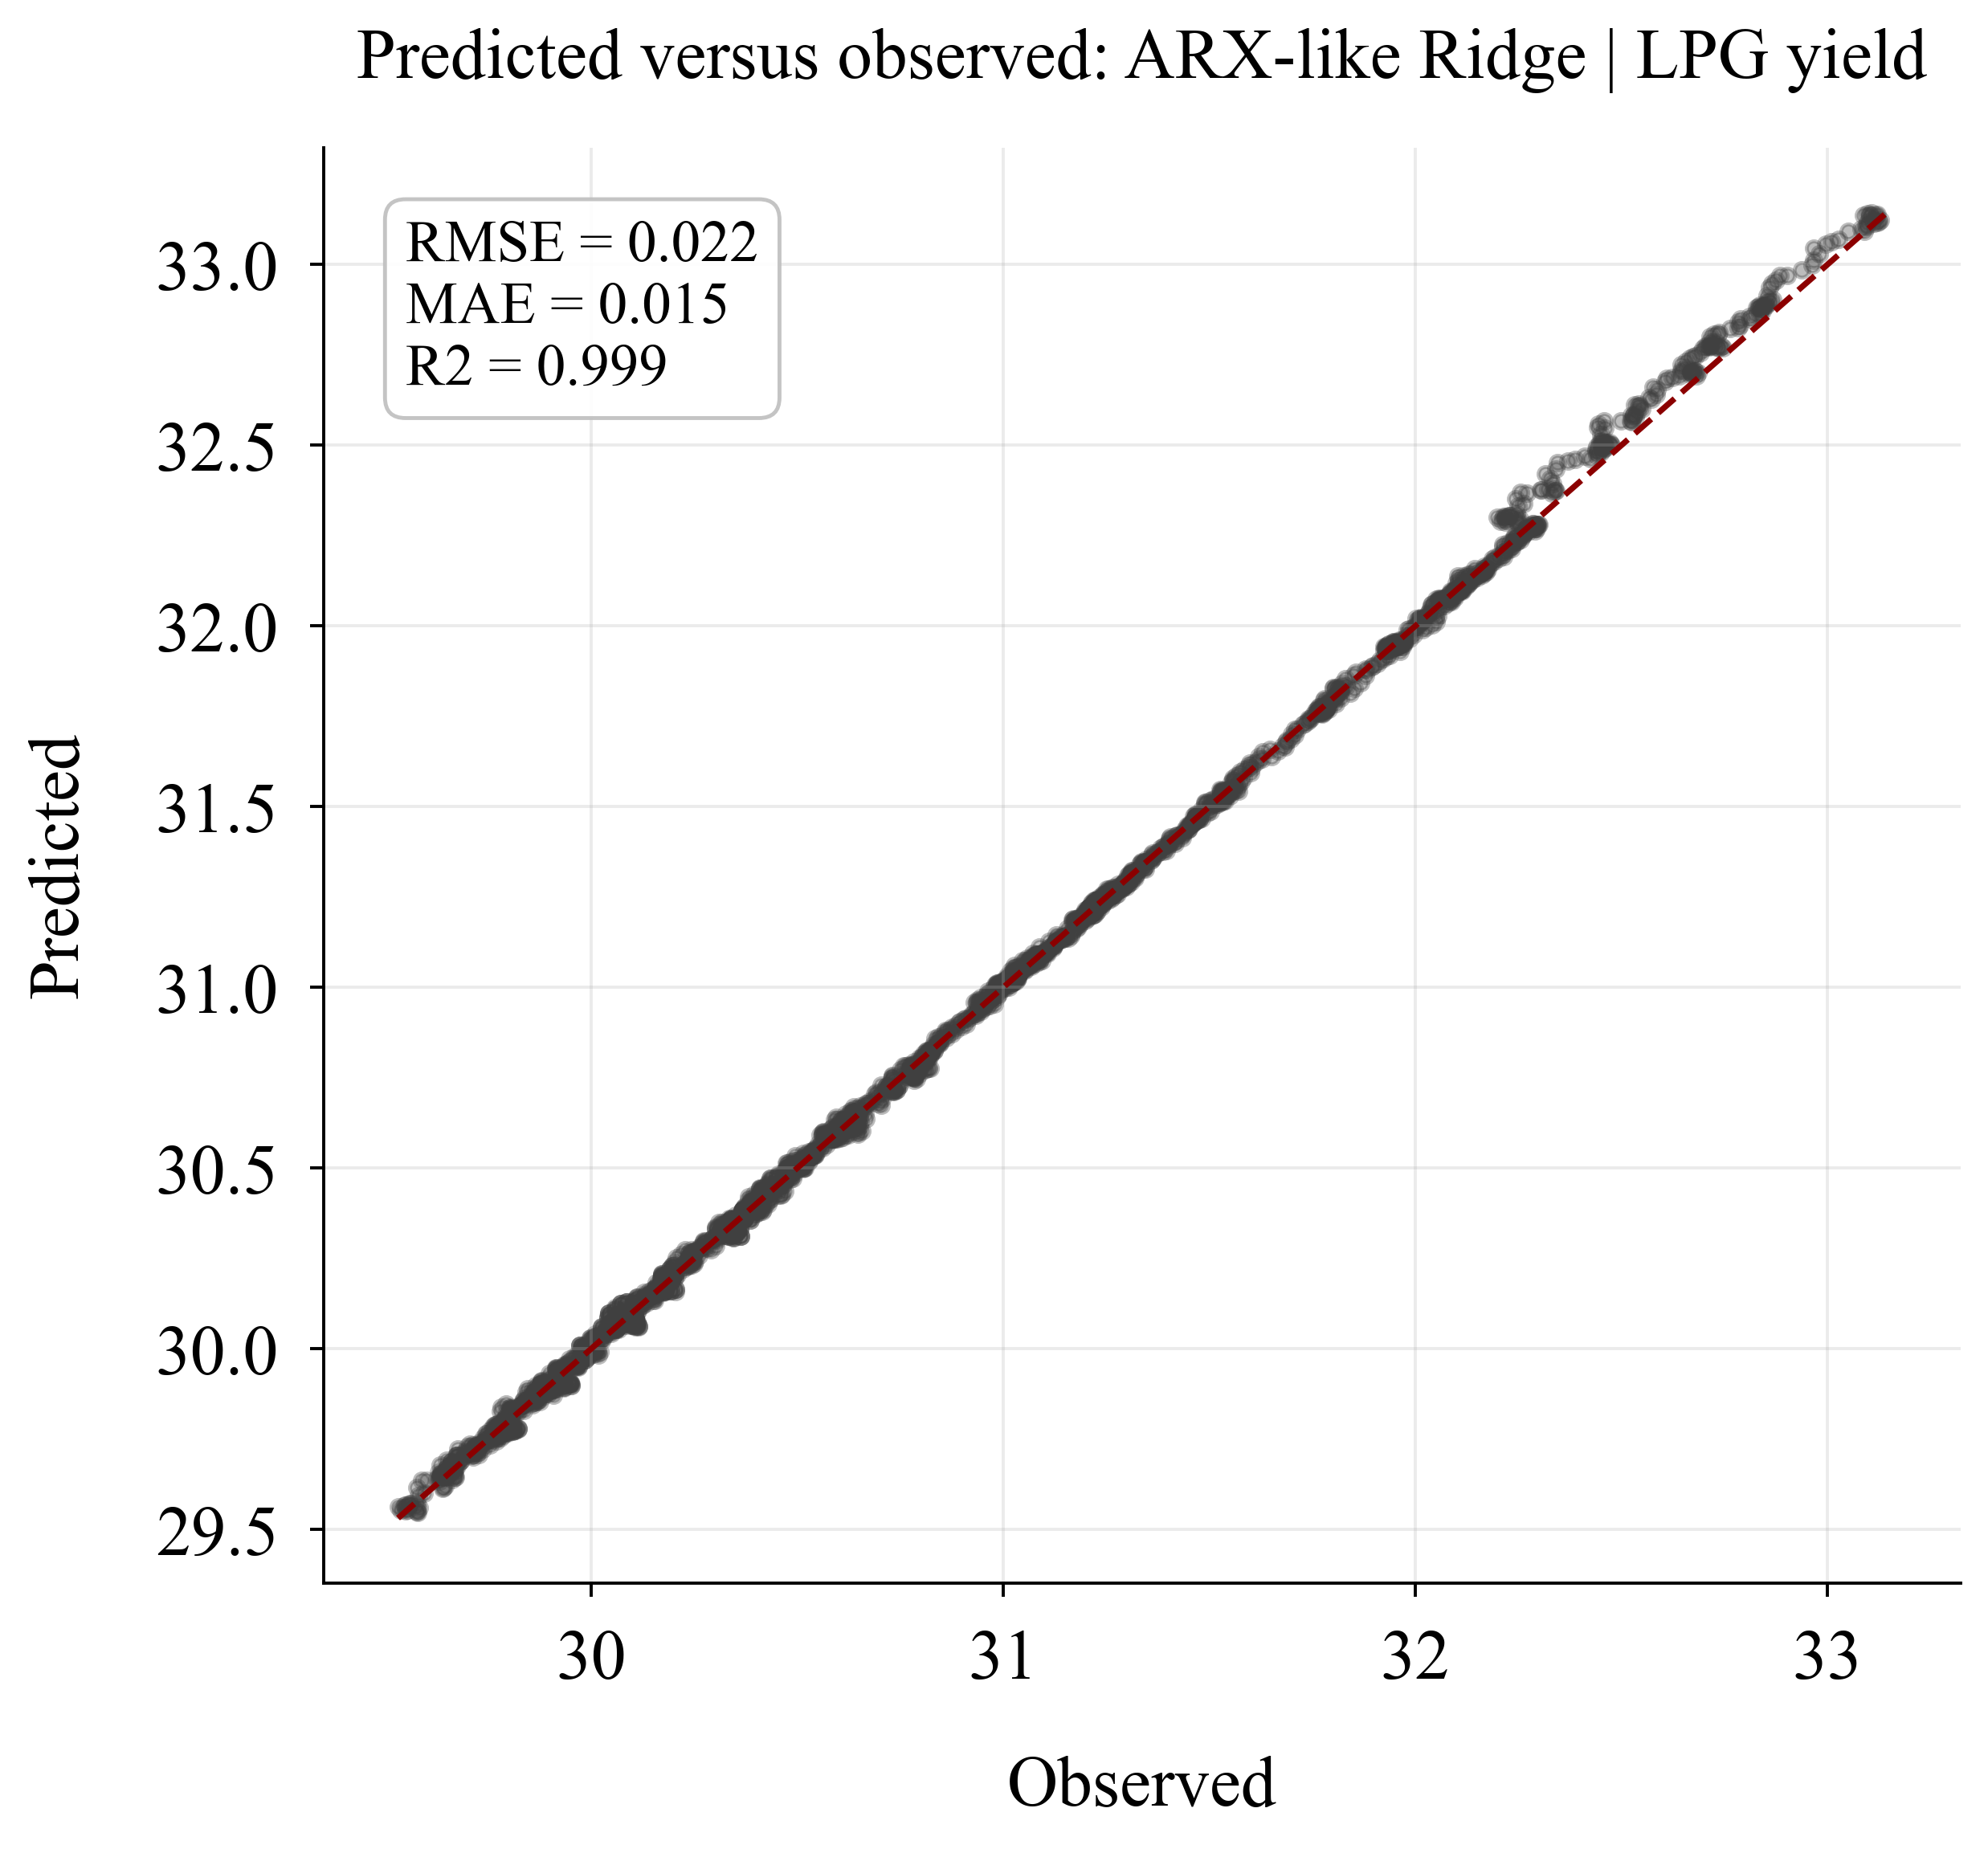

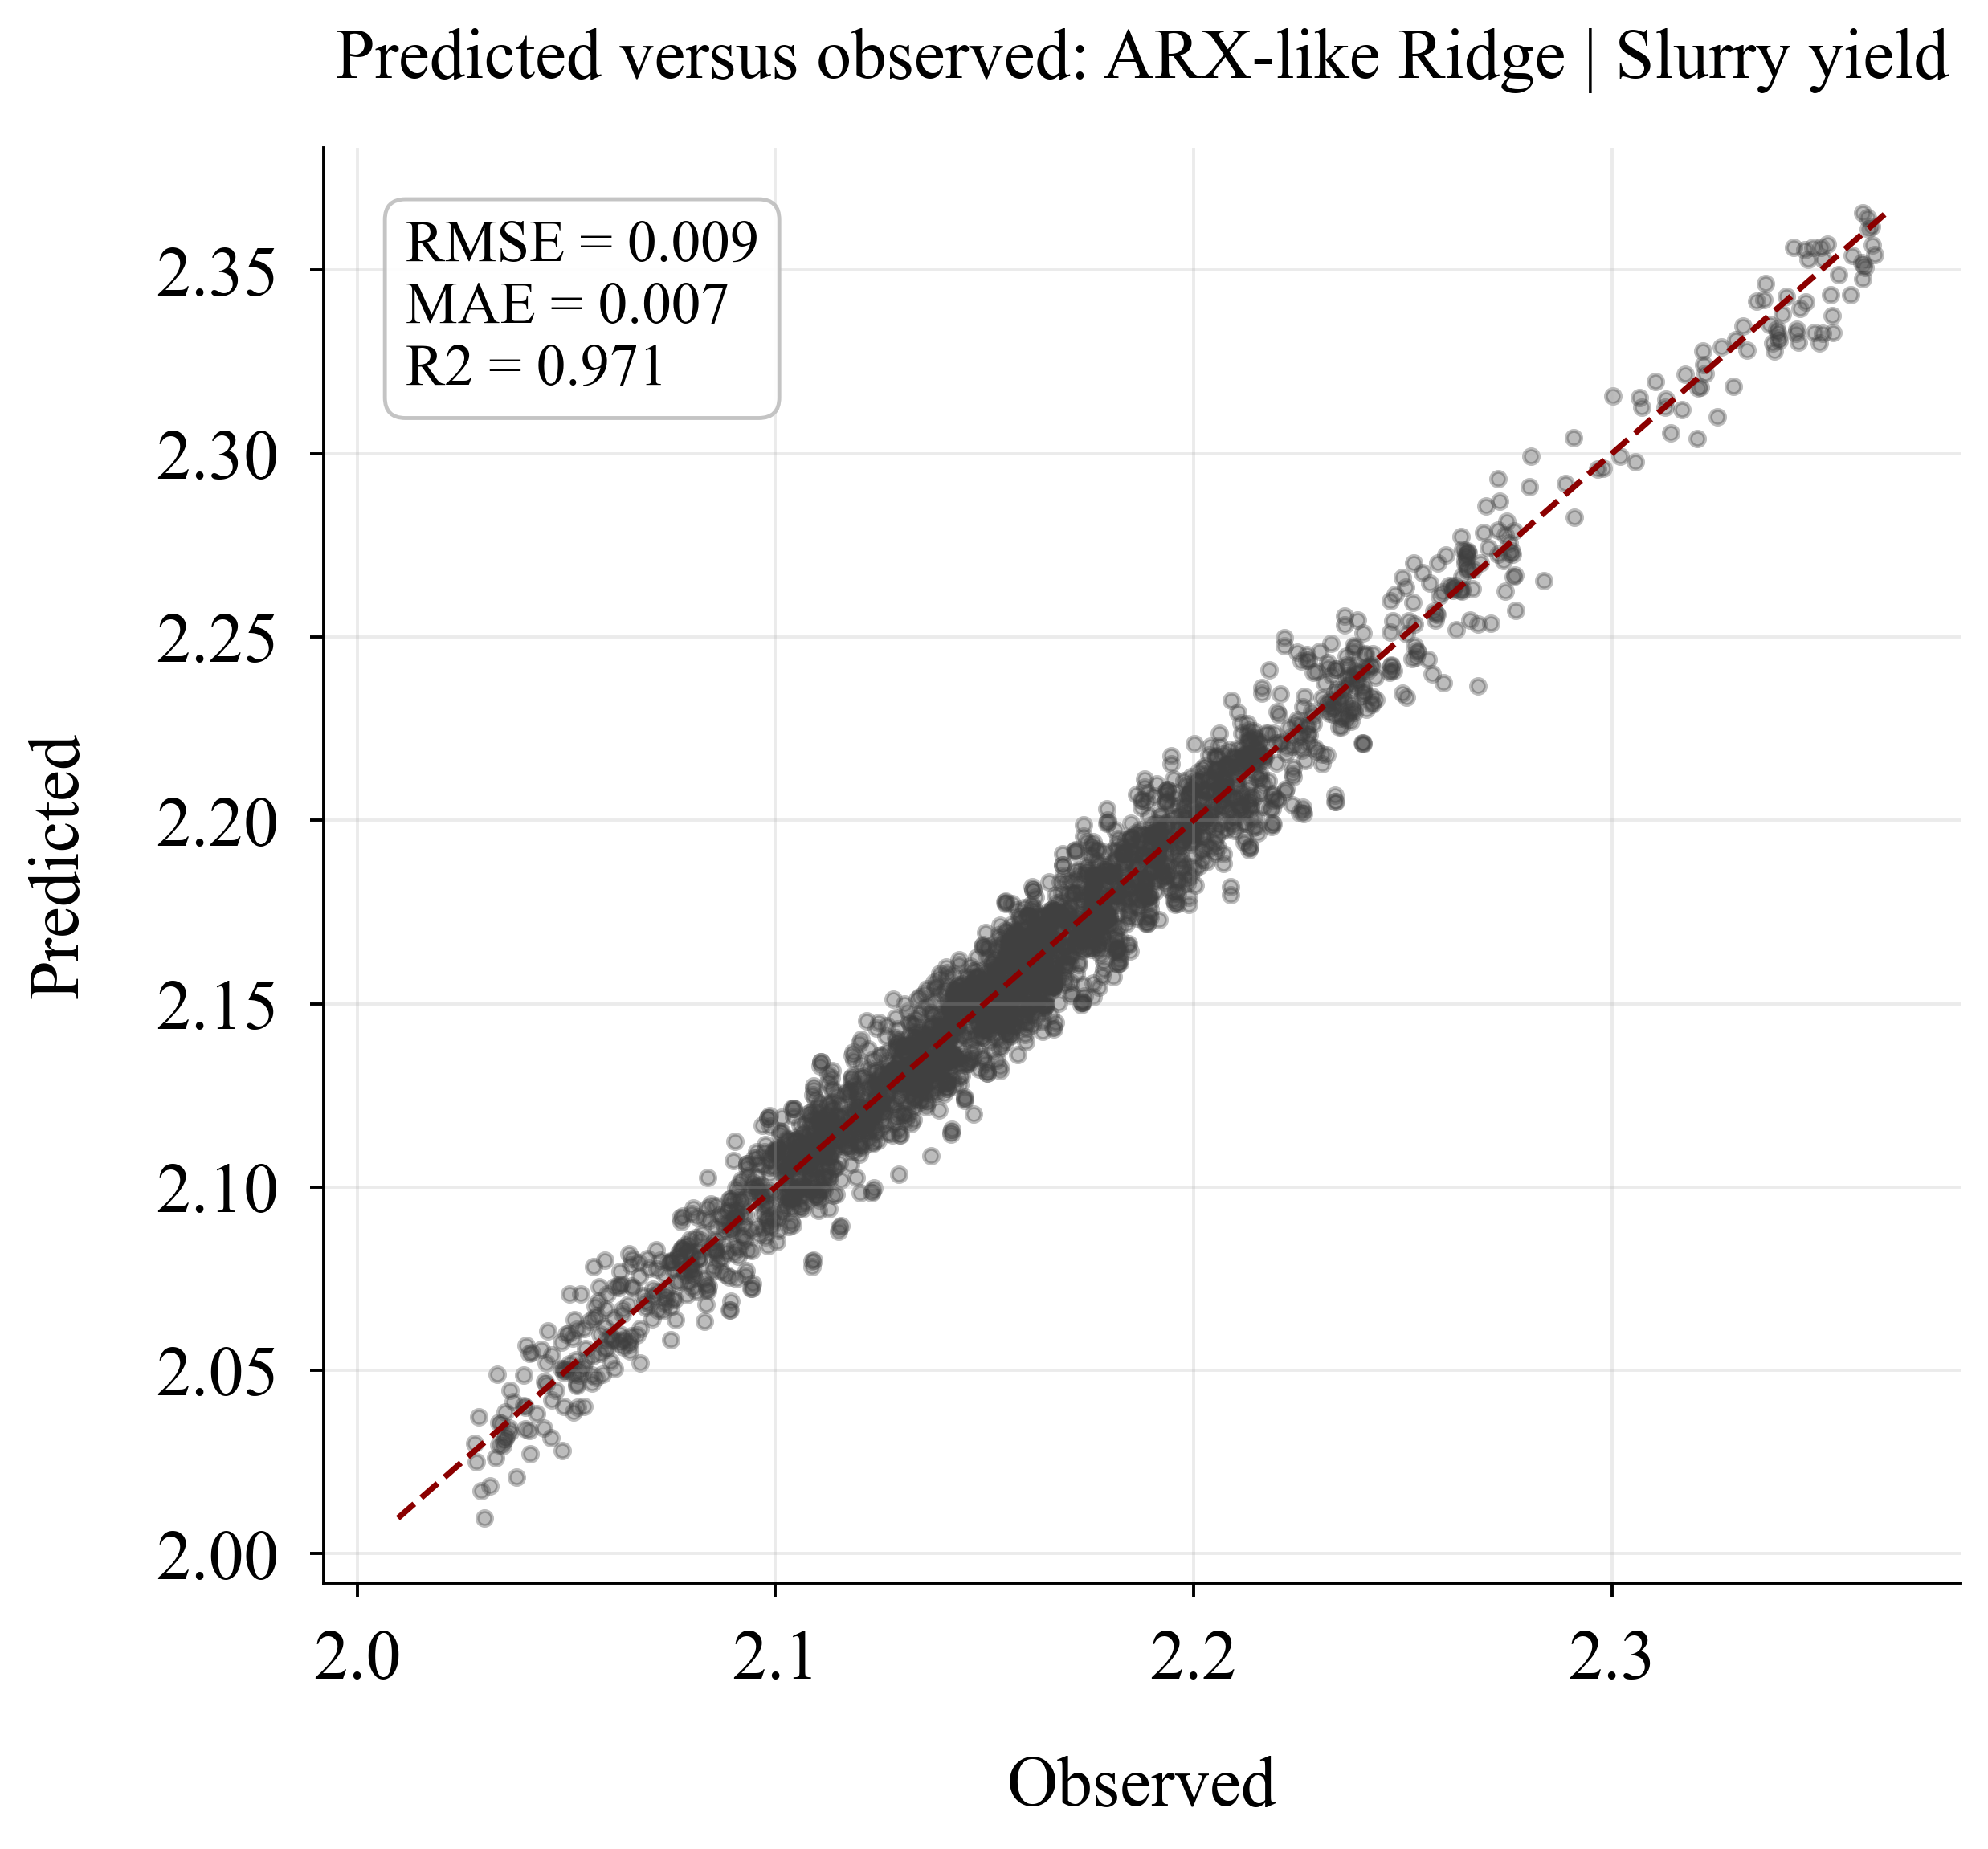

In [7]:
metrics_df = pd.concat(metrics_rows, ignore_index=True)
comparison_df = pd.DataFrame(comparison_rows).sort_values(['test_rmse', 'validation_rmse']).reset_index(drop=True)
formatted_comparison_df = format_best_in_table(
    comparison_df[['model', 'family', 'input_set', 'validation_rmse', 'validation_mae', 'validation_r2', 'test_rmse', 'test_mae', 'test_r2', 'test_smape', 'parameter_count', 'training_time_sec', 'inference_time_ms', 'best_validation_epoch']].copy(),
    lower_is_better_cols=['validation_rmse', 'validation_mae', 'test_rmse', 'test_mae', 'test_smape', 'training_time_sec', 'inference_time_ms'],
    higher_is_better_cols=['validation_r2', 'test_r2'],
)
display(formatted_comparison_df)

ml_test_macro_df = metrics_df.query("split == 'test' and target == 'macro'").sort_values('rmse').reset_index(drop=True)
display(ml_test_macro_df)

ml_target_rmse_df = metrics_df.query("split == 'test' and target != 'macro'").pivot_table(index='model', columns='target', values='rmse').sort_index()
display(ml_target_rmse_df)

horizontal_bar_plot(
    labels=ml_test_macro_df['model'][::-1],
    values=ml_test_macro_df['rmse'][::-1],
    title='Test macro RMSE across FCCU machine-learning baselines',
    xlabel='Macro RMSE',
    color='0.35',
    fmt='{:.4f}',
)

best_exogenous_model = comparison_df.query("input_set == 'exogenous_only'").sort_values('test_rmse').iloc[0]['model']
best_arx_model = comparison_df.query("model == 'ARX-like Ridge'").iloc[0]['model']
reference_models = [best_exogenous_model, best_arx_model]

meta_test = bundle_arx['splits']['test']['meta'].copy()
meta_test['phase_group'] = make_phase_group(meta_test)
subgroup_frames = []
for model_name in reference_models:
    preds = model_outputs[model_name]['predictions']['test']
    truth = model_outputs[model_name]['truth']['test']
    subgroup_frames.append(grouped_metrics_from_meta(truth, preds, meta_test, 'condition', model_name))
    subgroup_frames.append(grouped_metrics_from_meta(truth, preds, meta_test, 'phase_group', model_name))
subgroup_metrics_df = pd.concat(subgroup_frames, ignore_index=True)
display(subgroup_metrics_df)

condition_plot_df = subgroup_metrics_df.query("group == 'condition'").copy()
condition_plot_df['group_value'] = pd.Categorical(condition_plot_df['group_value'], categories=['normal', 'faulty'], ordered=True)
condition_plot_df = condition_plot_df.sort_values(['model', 'group_value'])
fig, ax = create_figure(figsize=(10.8, 6.0))
for model_name in reference_models:
    sub = condition_plot_df.query('model == @model_name').sort_values('group_value')
    ax.plot(sub['group_value'], sub['macro_rmse'], marker='o', linewidth=2.2, label=model_name)
style_axis(ax, 'Normal versus faulty macro RMSE for the selected ML models', 'Condition', 'Macro RMSE', grid_axis='both')
place_legend(ax, location='outside_right', ncol=1)
finalize_figure(fig, top=0.86, bottom=0.18, left=0.12, right=0.79)
show_and_close(fig)

for model_name in reference_models:
    preds = model_outputs[model_name]['predictions']['test']
    truth = model_outputs[model_name]['truth']['test']
    for col_idx, target_name in enumerate(primary_targets):
        metric_row = metrics_df.query("split == 'test' and model == @model_name and target == @target_name").iloc[0]
        fig, ax = create_figure(figsize=(7.1, 6.9))
        ax.scatter(truth[:, col_idx], preds[:, col_idx], s=14, alpha=0.35, color='0.25')
        line_min = min(truth[:, col_idx].min(), preds[:, col_idx].min())
        line_max = max(truth[:, col_idx].max(), preds[:, col_idx].max())
        ax.plot([line_min, line_max], [line_min, line_max], color='darkred', linewidth=1.5, linestyle='--')
        style_axis(ax, f'Predicted versus observed: {model_name} | {base_label(target_name)}', 'Observed', 'Predicted', grid_axis='both')
        ax.text(
            0.05,
            0.95,
            f"RMSE = {metric_row['rmse']:.3f}\nMAE = {metric_row['mae']:.3f}\nR2 = {metric_row['r2']:.3f}",
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=15,
            bbox={'boxstyle': 'round,pad=0.35', 'facecolor': 'white', 'edgecolor': '0.75', 'alpha': 0.92},
        )
        finalize_figure(fig, top=0.88, bottom=0.14, left=0.14, right=0.96)
        show_and_close(fig)
